# Run this to enable loading from relative paths

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 1
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Force matplotlib inlining 

In [2]:
%matplotlib inline

# Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Figures Save Path

In [4]:
global_save_figs = True

In [5]:
import pathlib
save_prefix = r"../results/tracking/"
if global_save_figs:
    try:
        pathlib.Path(save_prefix).mkdir(exist_ok=True)
    except:
        print("Failed to create save dir...")

# Load data

In [6]:
import pandas as pd
df_track = pd.read_pickle(r"../data/tracking/df_SLEAP_tracking.pkl")
df_behavior = pd.read_pickle(r"../data/tracking/df_behavior_tracked.pkl")

In [7]:
df_track

,track,frame_idx,instance.score,screw.x,screw.y,screw.score,E_L.x,E_L.y,E_L.score,L_L.x,...,L_R.x,L_R.y,L_R.score,T.x,T.y,T.score,source_file,src_filename,timestamp,timestamp_str
818,track_0,0,0.814842,420.721130,357.170288,1.009511,305.019836,401.652832,0.336312,NaN,...,500.518829,196.668533,0.720333,NaN,NaN,0.000000,labels_train_gt_0 Hatem2.003_images_2025-10-22...,2025-10-22 15_05_20,1.761138e+09,Wed Oct 22 15:05:20 2025
819,track_0,1,0.973108,420.995483,356.535156,1.021335,305.599518,395.625427,0.391039,NaN,...,500.858704,183.847153,0.640039,NaN,NaN,0.000000,labels_train_gt_0 Hatem2.003_images_2025-10-22...,2025-10-22 15_05_20,1.761138e+09,Wed Oct 22 15:05:20 2025
820,track_0,2,0.978962,420.811707,356.549042,1.014206,308.454651,396.310638,0.677545,269.620667,...,500.447021,184.132599,0.672030,NaN,NaN,0.000000,labels_train_gt_0 Hatem2.003_images_2025-10-22...,2025-10-22 15_05_20,1.761138e+09,Wed Oct 22 15:05:20 2025
821,track_0,3,0.959851,420.332703,356.937866,1.006969,308.059540,393.054962,0.568674,268.370758,...,499.605865,177.517761,0.627014,NaN,NaN,0.000000,labels_train_gt_0 Hatem2.003_images_2025-10-22...,2025-10-22 15_05_20,1.761138e+09,Wed Oct 22 15:05:20 2025
822,track_0,4,0.878448,420.485840,357.059631,1.006336,305.026093,389.618713,0.394221,260.172607,...,492.511169,173.457062,0.803072,NaN,NaN,0.000000,labels_train_gt_0 Hatem2.003_images_2025-10-22...,2025-10-22 15_05_20,1.761138e+09,Wed Oct 22 15:05:20 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98724,NaN,17,0.783003,420.279602,356.625854,0.984962,NaN,NaN,0.000000,NaN,...,NaN,NaN,0.000000,272.327271,160.690292,0.865445,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025
98725,NaN,18,0.797952,420.378357,356.531433,0.987066,NaN,NaN,0.000000,NaN,...,NaN,NaN,0.000000,275.798004,163.966415,0.855917,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025
98726,NaN,19,0.775720,420.475464,356.294830,0.985120,NaN,NaN,0.000000,NaN,...,NaN,NaN,0.000000,276.767334,168.233978,0.866021,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025
98727,NaN,20,0.682192,420.859589,356.775208,0.987660,NaN,NaN,0.000000,200.844635,...,NaN,NaN,0.000000,269.462280,180.374603,0.801219,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025


In [8]:
import time
# Set system time for stimulus end. This is useful for aligning with video timestamps.
df_behavior["StimEndSysTime"] = df_behavior.TrialStartSysTime + df_behavior.StimulusStartTime + df_behavior.calcStimulusTime
df_behavior["StimEndSysTimeStr"]  = df_behavior.StimEndSysTime.dropna().apply(lambda x: time.ctime(x))
df_behavior[["StimEndSysTime", "StimEndSysTimeStr"]].sort_values("StimEndSysTime").dropna()

,StimEndSysTime,StimEndSysTimeStr
683,1.761147e+09,Wed Oct 22 17:24:37 2025
684,1.761147e+09,Wed Oct 22 17:24:49 2025
685,1.761147e+09,Wed Oct 22 17:24:56 2025
686,1.761147e+09,Wed Oct 22 17:25:03 2025
687,1.761147e+09,Wed Oct 22 17:25:11 2025
...,...,...
2774,1.761318e+09,Fri Oct 24 16:53:14 2025
2775,1.761318e+09,Fri Oct 24 16:53:19 2025
2776,1.761318e+09,Fri Oct 24 16:53:25 2025
2777,1.761318e+09,Fri Oct 24 16:53:34 2025


# Sync dfs together

In [9]:
import time
fnames = df_track.source_file.str.split('.').str[1]
assert fnames.apply(len).nunique() == 1, "Some string splits did not work as expected!"
fnames = fnames.str.split("images_").str[1]
assert fnames.apply(len).nunique() == 1, "Some string splits did not work as expected!"
# Avoid copy warning
df_track = df_track.copy()
# Convert to unix timestamp
timestamps = fnames.apply(lambda x: time.mktime(time.strptime(x, "%Y-%m-%d %H_%M_%S")))
df_track['src_filename'] = fnames
df_track["timestamp"] = timestamps
df_track["timestamp_str"] = timestamps.apply(lambda x: time.ctime(x))

df_track_uniq_time = df_track[["src_filename", "timestamp", "timestamp_str",
                              ]].drop_duplicates().sort_values("timestamp")
df_track_uniq_time

,src_filename,timestamp,timestamp_str
22768,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025
22834,2025-10-22 13_33_56,1.761133e+09,Wed Oct 22 13:33:56 2025
22906,2025-10-22 13_34_03,1.761133e+09,Wed Oct 22 13:34:03 2025
22934,2025-10-22 13_34_07,1.761133e+09,Wed Oct 22 13:34:07 2025
22980,2025-10-22 13_34_15,1.761133e+09,Wed Oct 22 13:34:15 2025
...,...,...,...
98620,2025-10-24 12_53_12,1.761303e+09,Fri Oct 24 12:53:12 2025
98642,2025-10-24 12_53_18,1.761303e+09,Fri Oct 24 12:53:18 2025
98662,2025-10-24 12_53_23,1.761303e+09,Fri Oct 24 12:53:23 2025
98687,2025-10-24 12_53_32,1.761303e+09,Fri Oct 24 12:53:32 2025


In [ ]:
import matplotlib.pyplot as plt

def findNearestTime(df_track, df_mat, quick_test=False):
    df_track_li = []
    OFFSET_SECONDS = 60*60*4 + 2.2  # Adjust for time difference between tracking PC and behavior PC
    FRAMERATE = 30  # fps
    df_mat_used_idxs = set()
    df_mat = df_mat.reset_index(drop=True)
    for timestamp, timestamp_df in df_track.groupby("timestamp"):
        # Find nearest time in df_mat
        num_secs = len(timestamp_df) / FRAMERATE
        diffs = df_mat.StimEndSysTime - timestamp - OFFSET_SECONDS
        abs_diffs = diffs.abs()
        min_idx = abs_diffs.idxmin()
        df_mat_row = df_mat.loc[min_idx]
        nearest_time = df_mat_row["StimEndSysTime"]
        nearest_time_str = time.ctime(nearest_time)
        time_diff = diffs.loc[min_idx]
        record = {
            "timestamp": timestamp,
            "nearest_time": nearest_time,
            "nearest_time_str": nearest_time_str,
            "time_diff": time_diff,
            "n_rows": len(timestamp_df),
            "num_secs": num_secs,
            "idx": min_idx,
            "calcStimulusTime": df_mat.loc[min_idx, "calcStimulusTime"]
        }
        df_mat_used_idxs.add(min_idx)
        if quick_test:
            df_track_li.append(record)
            continue
        for _, row in timestamp_df.iterrows():
            ext_record = record.copy()
            for col in timestamp_df.columns:
                ext_record[f"track_{col}"] = row[col]
            for col in df_mat.columns:
                ext_record[col] = df_mat_row[col]
            df_track_li.append(ext_record)

    df_track_nearest = pd.DataFrame(df_track_li)
    time_diff = df_track_nearest.time_diff
    df_track_nearest = df_track_nearest[time_diff.abs() < 3]
    st_diff = df_track_nearest.calcStimulusTime - df_track_nearest.num_secs
    df_track_nearest = df_track_nearest[st_diff.abs() < .1]

    return df_track_nearest

df_track_nearest = findNearestTime(df_track, df_behavior, quick_test=False)
df_track_nearest

,timestamp,nearest_time,nearest_time_str,time_diff,n_rows,num_secs,idx,calcStimulusTime,track_track,track_frame_idx,...,Date,SessionNum,TrialNumber,TrialStartSysTime,StimulusStartTime,File,ChoiceLeft,quantile_idx,StimEndSysTime,StimEndSysTimeStr
0,1.761133e+09,1.761147e+09,Wed Oct 22 17:33:49 2025,-0.8277,66,2.200000,2080,2.2079,NaN,0,...,2025-10-22,3,5,1.761147e+09,0.9544,day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...,1.0,3.0,1.761147e+09,Wed Oct 22 17:33:49 2025
1,1.761133e+09,1.761147e+09,Wed Oct 22 17:33:49 2025,-0.8277,66,2.200000,2080,2.2079,NaN,1,...,2025-10-22,3,5,1.761147e+09,0.9544,day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...,1.0,3.0,1.761147e+09,Wed Oct 22 17:33:49 2025
2,1.761133e+09,1.761147e+09,Wed Oct 22 17:33:49 2025,-0.8277,66,2.200000,2080,2.2079,NaN,2,...,2025-10-22,3,5,1.761147e+09,0.9544,day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...,1.0,3.0,1.761147e+09,Wed Oct 22 17:33:49 2025
3,1.761133e+09,1.761147e+09,Wed Oct 22 17:33:49 2025,-0.8277,66,2.200000,2080,2.2079,NaN,3,...,2025-10-22,3,5,1.761147e+09,0.9544,day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...,1.0,3.0,1.761147e+09,Wed Oct 22 17:33:49 2025
4,1.761133e+09,1.761147e+09,Wed Oct 22 17:33:49 2025,-0.8277,66,2.200000,2080,2.2079,NaN,4,...,2025-10-22,3,5,1.761147e+09,0.9544,day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...,1.0,3.0,1.761147e+09,Wed Oct 22 17:33:49 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93646,1.761303e+09,1.761318e+09,Fri Oct 24 16:53:39 2025,-0.3995,22,0.733333,922,0.7277,NaN,17,...,2025-10-24,1,249,1.761318e+09,0.8708,day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...,1.0,1.0,1.761318e+09,Fri Oct 24 16:53:39 2025
93647,1.761303e+09,1.761318e+09,Fri Oct 24 16:53:39 2025,-0.3995,22,0.733333,922,0.7277,NaN,18,...,2025-10-24,1,249,1.761318e+09,0.8708,day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...,1.0,1.0,1.761318e+09,Fri Oct 24 16:53:39 2025
93648,1.761303e+09,1.761318e+09,Fri Oct 24 16:53:39 2025,-0.3995,22,0.733333,922,0.7277,NaN,19,...,2025-10-24,1,249,1.761318e+09,0.8708,day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...,1.0,1.0,1.761318e+09,Fri Oct 24 16:53:39 2025
93649,1.761303e+09,1.761318e+09,Fri Oct 24 16:53:39 2025,-0.3995,22,0.733333,922,0.7277,NaN,20,...,2025-10-24,1,249,1.761318e+09,0.8708,day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...,1.0,1.0,1.761318e+09,Fri Oct 24 16:53:39 2025


In [11]:
def reorderTrackCols(df_track_nearest):
    track_cols = [col for col in df_track_nearest.columns if col.startswith("track_")]
    other_cols = [col for col in df_track_nearest.columns if not col.startswith("track_")]
    df_track_nearest = df_track_nearest[track_cols + other_cols]
    return df_track_nearest, track_cols

df_track_nearest, track_cols = reorderTrackCols(df_track_nearest)
# df_track_nearest.File.unique()
df_track_nearest[track_cols]

,track_track,track_frame_idx,track_instance.score,track_screw.x,track_screw.y,track_screw.score,track_E_L.x,track_E_L.y,track_E_L.score,track_L_L.x,...,track_L_R.x,track_L_R.y,track_L_R.score,track_T.x,track_T.y,track_T.score,track_source_file,track_src_filename,track_timestamp,track_timestamp_str
0,NaN,0,0.843577,417.282135,359.940247,0.975344,297.281128,371.955261,0.771175,288.750977,...,504.845551,163.963470,0.506103,349.609070,128.398865,0.429217,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025
1,NaN,1,0.890157,417.232788,360.227173,0.973041,300.541534,372.331177,0.827402,288.829712,...,508.884491,164.707397,0.528610,352.180817,125.008858,0.468019,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025
2,NaN,2,0.846205,416.507751,360.511963,0.960343,296.522980,372.697876,0.841339,292.265564,...,511.846008,168.689423,0.484388,352.281799,124.904861,0.325119,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025
3,NaN,3,0.887406,417.001892,360.532593,0.970213,296.991882,372.380554,0.771671,288.751068,...,508.772308,168.573425,0.537285,349.429138,124.942909,0.424967,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025
4,NaN,4,0.899301,417.062561,360.322632,0.975312,296.834229,372.171814,0.846909,288.460571,...,508.762604,168.865662,0.530651,349.483246,124.643158,0.432056,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93646,NaN,17,0.783003,420.279602,356.625854,0.984962,NaN,NaN,0.000000,NaN,...,NaN,NaN,0.000000,272.327271,160.690292,0.865445,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025
93647,NaN,18,0.797952,420.378357,356.531433,0.987066,NaN,NaN,0.000000,NaN,...,NaN,NaN,0.000000,275.798004,163.966415,0.855917,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025
93648,NaN,19,0.775720,420.475464,356.294830,0.985120,NaN,NaN,0.000000,NaN,...,NaN,NaN,0.000000,276.767334,168.233978,0.866021,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025
93649,NaN,20,0.682192,420.859589,356.775208,0.987660,NaN,NaN,0.000000,200.844635,...,NaN,NaN,0.000000,269.462280,180.374603,0.801219,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025


In [12]:
df_track_nearest.File.str.split("\\").str[-3:].str.join("/")

0        day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...
1        day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...
2        day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...
3        day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...
4        day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Sessio...
                               ...                        
93646    day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...
93647    day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...
93648    day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...
93649    day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...
93650    day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Sessio...
Name: File, Length: 76311, dtype: object

In [13]:
from pathlib import Path
import os
sess_top_ref_dict = {
    # day 1
    'day1/MLA-73/MLA-73_Mouse2AFC_Oct22_2025_Session1.mat':(405,49),
    'day1/MLA-74/MLA-74_Mouse2AFC_Oct22_2025_Session2.mat':(405,49),
    'day1/MLA-75/MLA-75_Mouse2AFC_Oct22_2025_Session2.mat':(405,60),
    'day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Session3.mat':(406,54),
    # day 2
    'day2/MLA-73/MLA-73_Mouse2AFC_Oct23_2025_Session2.mat':(405,55),
    'day2/MLA-74/MLA-74_Mouse2AFC_Oct23_2025_Session1.mat':(405,55),
    'day2/MLA-75/MLA-75_Mouse2AFC_Oct23_2025_Session1.mat':(405,55),
    'day2/MLA-76/MLA-76_Mouse2AFC_Oct23_2025_Session1.mat':(405,55),
    # day 3
    'day3/MLA-73/MLA-73_Mouse2AFC_Oct24_2025_Session1.mat':(401,61),
    'day3/MLA-74/MLA-74_Mouse2AFC_Oct24_2025_Session1.mat':(407,55),
    'day3/MLA-75/MLA-75_Mouse2AFC_Oct24_2025_Session1.mat':(406,50),
    'day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Session1.mat':(406,55),
}
def assignTopRef(df):
    mapFn = lambda fp, tup_idx: sess_top_ref_dict[fp][tup_idx]
    df = df.copy()
    df['track_TopRef.x'] = df.File.apply(mapFn, args=(0,))
    df['track_TopRef.y'] = df.File.apply(mapFn, args=(1,))
    missing_top_ref = df["track_TopRef.x"].isna().sum()
    assert missing_top_ref == 0, f"Some files are missing SessTopRef mapping: {missing_top_ref} rows"
    return df

df_track_nearest = assignTopRef(df_track_nearest)
df_track_nearest, track_cols = reorderTrackCols(df_track_nearest)
df_track_nearest[track_cols]

,track_track,track_frame_idx,track_instance.score,track_screw.x,track_screw.y,track_screw.score,track_E_L.x,track_E_L.y,track_E_L.score,track_L_L.x,...,track_L_R.score,track_T.x,track_T.y,track_T.score,track_source_file,track_src_filename,track_timestamp,track_timestamp_str,track_TopRef.x,track_TopRef.y
0,NaN,0,0.843577,417.282135,359.940247,0.975344,297.281128,371.955261,0.771175,288.750977,...,0.506103,349.609070,128.398865,0.429217,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025,406,54
1,NaN,1,0.890157,417.232788,360.227173,0.973041,300.541534,372.331177,0.827402,288.829712,...,0.528610,352.180817,125.008858,0.468019,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025,406,54
2,NaN,2,0.846205,416.507751,360.511963,0.960343,296.522980,372.697876,0.841339,292.265564,...,0.484388,352.281799,124.904861,0.325119,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025,406,54
3,NaN,3,0.887406,417.001892,360.532593,0.970213,296.991882,372.380554,0.771671,288.751068,...,0.537285,349.429138,124.942909,0.424967,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025,406,54
4,NaN,4,0.899301,417.062561,360.322632,0.975312,296.834229,372.171814,0.846909,288.460571,...,0.530651,349.483246,124.643158,0.432056,labels_train_gt_0 Hatem3.242_images_2025-10-22...,2025-10-22 13_33_48,1.761133e+09,Wed Oct 22 13:33:48 2025,406,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93646,NaN,17,0.783003,420.279602,356.625854,0.984962,NaN,NaN,0.000000,NaN,...,0.000000,272.327271,160.690292,0.865445,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025,406,55
93647,NaN,18,0.797952,420.378357,356.531433,0.987066,NaN,NaN,0.000000,NaN,...,0.000000,275.798004,163.966415,0.855917,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025,406,55
93648,NaN,19,0.775720,420.475464,356.294830,0.985120,NaN,NaN,0.000000,NaN,...,0.000000,276.767334,168.233978,0.866021,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025,406,55
93649,NaN,20,0.682192,420.859589,356.775208,0.987660,NaN,NaN,0.000000,200.844635,...,0.000000,269.462280,180.374603,0.801219,labels_train_gt_0 Hatem7.513_images_2025-10-24...,2025-10-24 12_53_38,1.761303e+09,Fri Oct 24 12:53:38 2025,406,55


In [14]:
[col for col in df_track_nearest.columns if "track_" in col.lower() and (".x" in col.lower())]
# There is an equivlent .y version of these columns

['track_screw.x',
 'track_E_L.x',
 'track_L_L.x',
 'track_E_R.x',
 'track_L_R.x',
 'track_T.x',
 'track_TopRef.x']

# Rotate to reference

In [15]:
TRACK_COLS = ['track_E_L',
              'track_L_L',
              'track_E_R',
              'track_L_R',
              'track_T',
            ]

In [16]:
import numpy as np

def analyze_rois(base, top, rois):
    """
    base, top: shape (2,) arrays-like
    rois: shape (N, 2) array-like of ROI points
    Returns dict with x', y', normalized versions, angles (rad & deg), and normalized radial distance.
    """
    B = np.asarray(base, dtype=float)
    T = np.asarray(top, dtype=float)
    R = np.asarray(rois, dtype=float)  # (N,2)

    u = T - B
    L = np.linalg.norm(u)
    if L == 0:
        raise ValueError("Base and Top coincide; direction is undefined.")

    e = u / L                            # axis along B->T
    p = np.array([-e[1], e[0]])          # +90° perpendicular

    V = R - B                            # translate to base

    # coordinates in the aligned frame
    y_prime = V @ e                      # along-axis component
    x_prime = V @ p                      # perpendicular component

    # angles
    dot = (V @ u)                        # (u·v) for each ROI
    cross = u[0]*V[:,1] - u[1]*V[:,0]    # 2D scalar cross u x v
    theta = np.arctan2(cross, dot)       # signed angle (radians)
    theta_deg = np.degrees(theta)

    # distances
    v_norm = np.linalg.norm(V, axis=1)
    d_norm = v_norm / L

    # normalized coordinates (one unit = |B-T|)
    x_norm = x_prime / L
    y_norm = y_prime / L

    return {
        "x_prime": x_prime, "y_prime": y_prime,
        "x_norm": x_norm,   "y_norm": y_norm,
        "theta_rad": theta, "theta_deg": theta_deg,
        "d_norm": d_norm
    }

def rotateToReference(df):
    df = df.copy()
    for sess, sess_df in df.groupby("File"):
        screw_x = sess_df['track_screw.x']
        screw_y = sess_df['track_screw.y']
        print(f"Session: {sess}")# - Base screw ({screw_x.iloc[0]}, {screw_y.iloc[0]})")
        # display(screw_x.describe())
        # display(screw_y.describe())
        screw_x_median = screw_x.median()
        screw_y_median = screw_y.median()
        print(f"  Base screw median: ({screw_x_median}, {screw_y_median})")
        # Top ref is fixed and set manually by the user, all values are the same
        top_ref_x = sess_df['track_TopRef.x'].iloc[0]
        top_ref_y = sess_df['track_TopRef.y'].iloc[0]
        for track_col in TRACK_COLS + ['track_TopRef']:
            col_x = f"{track_col}.x"
            col_y = f"{track_col}.y"
            rois = sess_df[[col_x, col_y]].to_numpy()
            analysis_res = analyze_rois(
                base=(screw_x_median, screw_y_median),
                top=(top_ref_x, top_ref_y),
                rois=rois
            )
            for key, values in analysis_res.items():
                new_col_name = f"{col_x}_{key}"
                df.loc[sess_df.index, new_col_name] = values
    return df

df_track_nearest_rot = rotateToReference(df_track_nearest)
df_track_nearest_rot, track_cols = reorderTrackCols(df_track_nearest_rot)
df_track_nearest_rot[track_cols]

Session: day1/MLA-73/MLA-73_Mouse2AFC_Oct22_2025_Session1.mat
  Base screw median: (420.5240478515625, 356.795166015625)
Session: day1/MLA-74/MLA-74_Mouse2AFC_Oct22_2025_Session2.mat
  Base screw median: (417.2786865234375, 360.23797607421875)
Session: day1/MLA-75/MLA-75_Mouse2AFC_Oct22_2025_Session2.mat
  Base screw median: (416.7042541503906, 360.4030456542969)
Session: day1/MLA-76/MLA-76_Mouse2AFC_Oct22_2025_Session3.mat
  Base screw median: (419.975341796875, 357.62469482421875)
Session: day2/MLA-73/MLA-73_Mouse2AFC_Oct23_2025_Session2.mat
  Base screw median: (419.84710693359375, 360.0956420898437)
Session: day2/MLA-74/MLA-74_Mouse2AFC_Oct23_2025_Session1.mat
  Base screw median: (412.55413818359375, 364.6865997314453)
Session: day2/MLA-75/MLA-75_Mouse2AFC_Oct23_2025_Session1.mat
  Base screw median: (417.2831726074219, 359.8474426269531)
Session: day2/MLA-76/MLA-76_Mouse2AFC_Oct23_2025_Session1.mat
  Base screw median: (420.341796875, 356.84544372558594)
Session: day3/MLA-73/MLA-

,track_track,track_frame_idx,track_instance.score,track_screw.x,track_screw.y,track_screw.score,track_E_L.x,track_E_L.y,track_E_L.score,track_L_L.x,...,track_T.x_theta_rad,track_T.x_theta_deg,track_T.x_d_norm,track_TopRef.x_x_prime,track_TopRef.x_y_prime,track_TopRef.x_x_norm,track_TopRef.x_y_norm,track_TopRef.x_theta_rad,track_TopRef.x_theta_deg,track_TopRef.x_d_norm
0,NaN,0,0.843577,417.282135,359.940247,0.975344,297.281128,371.955261,0.771175,288.750977,...,-0.251846,-14.429733,0.788900,1.776357e-15,303.946156,5.844314e-18,1.0,0.0,0.0,1.0
1,NaN,1,0.890157,417.232788,360.227173,0.973041,300.541534,372.331177,0.827402,288.829712,...,-0.237593,-13.613085,0.797160,1.776357e-15,303.946156,5.844314e-18,1.0,0.0,0.0,1.0
2,NaN,2,0.846205,416.507751,360.511963,0.960343,296.522980,372.697876,0.841339,292.265564,...,-0.237073,-13.583287,0.797395,1.776357e-15,303.946156,5.844314e-18,1.0,0.0,0.0,1.0
3,NaN,3,0.887406,417.001892,360.532593,0.970213,296.991882,372.380554,0.771671,288.751068,...,-0.248383,-14.231277,0.799948,1.776357e-15,303.946156,5.844314e-18,1.0,0.0,0.0,1.0
4,NaN,4,0.899301,417.062561,360.322632,0.975312,296.834229,372.171814,0.846909,288.460571,...,-0.247813,-14.198617,0.800840,1.776357e-15,303.946156,5.844314e-18,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93646,NaN,17,0.783003,420.279602,356.625854,0.984962,NaN,NaN,0.000000,NaN,...,-0.599510,-34.349387,0.813588,0.000000e+00,301.945628,0.000000e+00,1.0,0.0,0.0,1.0
93647,NaN,18,0.797952,420.378357,356.531433,0.987066,NaN,NaN,0.000000,NaN,...,-0.596227,-34.161276,0.798004,0.000000e+00,301.945628,0.000000e+00,1.0,0.0,0.0,1.0
93648,NaN,19,0.775720,420.475464,356.294830,0.985120,NaN,NaN,0.000000,NaN,...,-0.603776,-34.593789,0.784799,0.000000e+00,301.945628,0.000000e+00,1.0,0.0,0.0,1.0
93649,NaN,20,0.682192,420.859589,356.775208,0.987660,NaN,NaN,0.000000,200.844635,...,-0.660557,-37.847115,0.768757,0.000000e+00,301.945628,0.000000e+00,1.0,0.0,0.0,1.0


# Writing

In [17]:
import matplotlib.pyplot as plt
import tqdm.auto as tqdm
import cv2
import numpy as np

def _ref_axes(base, top):
    B = np.asarray(base, float)
    T = np.asarray(top, float)
    u = T - B
    L = np.hypot(u[0], u[1])
    if L == 0:
        raise ValueError("Base and Top coincide; direction is undefined.")
    e = u / L
    p = np.array([-e[1], e[0]], dtype=float)
    return B, e, p

def _affine_and_canvas(H, W, base, top):
    """
    Build warp M mapping (x,y)->(x',y') with:
      x' = p_x*(x-Bx) + p_y*(y-By)
      y' = e_x*(x-Bx) + e_y*(y-By)
    Then translate so the min (x',y') is at (0,0) and size canvas to fit the whole image.
    Returns: M (2x3 float32), dsize (W_out, H_out), extent (xmin,xmax,ymin,ymax)
    """
    B, e, p = _ref_axes(base, top)

    # Source corners in (x,y)
    corners = np.array([[0,0],[W,0],[0,H],[W,H]], dtype=np.float32)
    V = corners - B.astype(np.float32)
    x_prime = V[:,0]*p[0] + V[:,1]*p[1]
    y_prime = V[:,0]*e[0] + V[:,1]*e[1]

    x_min, x_max = np.floor(x_prime.min()), np.ceil(x_prime.max())
    y_min, y_max = np.floor(y_prime.min()), np.ceil(y_prime.max())

    # Translation so (x_min,y_min)->(0,0)
    tx, ty = -x_min, -y_min

    # x' = p·(x) - p·B + tx   ;   y' = e·(x) - e·B + ty
    t_pxB = p[0]*B[0] + p[1]*B[1]
    t_exB = e[0]*B[0] + e[1]*B[1]
    M = np.array([[p[0], p[1], float(tx - t_pxB)],
                  [e[0], e[1], float(ty - t_exB)]], dtype=np.float32)

    W_out = int(x_max - x_min + 1)
    H_out = int(y_max - y_min + 1)
    extent = (float(x_min), float(x_max), float(y_min), float(y_max))
    return M, (W_out, H_out), extent

def _to_uint8_bgr(frame, colored: bool, normalize_to_8bit: bool):
    """
    Ensure frame is uint8 BGR for VideoWriter.
    - If colored=True and frame is grayscale -> convert to BGR.
    - If dtype is not uint8 -> normalize to 0..255 per-frame (or clip/scale).
    """
    f = frame
    # Ensure 2D grayscale or 3D BGR only
    if f.ndim == 2:
        # grayscale
        if f.dtype != np.uint8:
            if normalize_to_8bit:
                f = cv2.normalize(f, None, 0, 255, cv2.NORM_MINMAX)
                f = f.astype(np.uint8)
            else:
                f = np.clip(f, 0, 255).astype(np.uint8)
        if colored:
            f = cv2.cvtColor(f, cv2.COLOR_GRAY2BGR)  # make 3-channel
        return f
    else:
        # 3-channel already
        if f.dtype != np.uint8:
            if normalize_to_8bit:
                f = cv2.normalize(f, None, 0, 255, cv2.NORM_MINMAX)
                f = f.astype(np.uint8)
            else:
                f = np.clip(f, 0, 255).astype(np.uint8)
        return f  # assume already BGR

def rotate_frame_cv2(img, M, dsize):
    # Linear interpolation; zeros outside source
    return cv2.warpAffine(img, M, dsize, flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)



# Interpolate missing points

In [ ]:
from pathlib import Path
import tqdm.auto as tqdm
import numpy as np

def getCoord(col_key, row):
    entry_x = row[f"{col_key}.x_x_prime"]
    entry_y = row[f"{col_key}.x_y_prime"]
    entry_score = row[f"{col_key}.score"]
    return entry_x, entry_y, entry_score

def _interpolateMissing(row,
                        avg_left_diff, avg_right_diff,
                        avg_shoulder_diff, avg_limb_diff):
    # Tail
    # t_xp, t_yp, t_score = getCoord('track_T', row) # We don't need tail here
    # Lateral Left Limb
    ll_xp, ll_yp, ll_score = getCoord('track_L_L', row)
    # Lateral Right Limb
    lr_xp, lr_yp, lr_score = getCoord('track_L_R', row)
    # Left shoulder
    el_xp, el_yp, el_score = getCoord('track_E_L', row)
    # Right shoulder
    er_xp, er_yp, er_score = getCoord('track_E_R', row)

    # Coount how many points are there
    limbs_points = np.sum(~np.isnan([ll_xp, lr_xp, el_xp, er_xp]))

    if limbs_points == 1 and (np.isfinite(el_xp) or np.isfinite(er_xp)):
        if np.isfinite(el_xp):
            # Estimate right shoulder
            er_xp, er_yp = el_xp + avg_shoulder_diff[0], el_yp + avg_shoulder_diff[1]
            er_score = -1
        else:
            # Estimate left shoulder
            el_xp, el_yp = er_xp - avg_shoulder_diff[0], er_yp - avg_shoulder_diff[1]
            el_score = -1
        limbs_points += 1
    elif limbs_points == 2:
        # Construct a missing point as amid point translated with an
        # offset equal to the average of the missing points
        # 2 average distances. This will us to build a triangle later.
        increment = True
        if np.isfinite(ll_xp) and np.isfinite(lr_xp):
            el_xp, el_yp = ll_xp + avg_left_diff[0], ll_yp + avg_left_diff[1]
            er_xp, er_yp = lr_xp + avg_right_diff[0], lr_yp + avg_right_diff[1]
            el_score = -1
            er_score = -1
        elif np.isfinite(el_xp) and np.isfinite(er_xp):
            ll_xp, ll_yp = el_xp - avg_left_diff[0], el_yp - avg_left_diff[1]
            lr_xp, lr_yp = er_xp - avg_right_diff[0], er_yp - avg_right_diff[1]
            ll_score = -1
            lr_score = -1
        elif np.isfinite(ll_xp) and np.isfinite(el_xp):
            lr_xp, lr_yp = ll_xp + avg_limb_diff[0], ll_yp + avg_limb_diff[1]
            er_xp, er_yp = el_xp + avg_shoulder_diff[0], el_yp + avg_shoulder_diff[1]
            lr_score = -1
            er_score = -1
        elif np.isfinite(lr_xp) and np.isfinite(er_xp):
            ll_xp, ll_yp = lr_xp - avg_limb_diff[0], lr_yp - avg_limb_diff[1]
            el_xp, el_yp = er_xp - avg_shoulder_diff[0], er_yp - avg_shoulder_diff[1]
            ll_score = -1
            el_score = -1
        elif np.isfinite(ll_xp) and np.isfinite(er_xp):
            lr_xp, lr_yp = ll_xp + avg_limb_diff[0], ll_yp + avg_limb_diff[1]
            el_xp, el_yp = er_xp - avg_shoulder_diff[0], er_yp - avg_shoulder_diff[1]
            lr_score = -1
            el_score = -1
        elif np.isfinite(lr_xp) and np.isfinite(el_xp):
            ll_xp, ll_yp = lr_xp - avg_limb_diff[0], lr_yp - avg_limb_diff[1]
            er_xp, er_yp = el_xp + avg_shoulder_diff[0], el_yp + avg_shoulder_diff[1]
            ll_score = -1
            er_score = -1
        else:
            increment = False
        #     raise RuntimeError("Logic error in limb point estimation")
        if increment:
            limbs_points += 2
    elif limbs_points == 3:
        # Check which 2 lateral points are available, and get their
        # difference and apply to estimate missing point
        if np.isfinite(ll_xp) and np.isfinite(el_xp):
            diff = np.array([ll_xp, ll_yp]) - np.array([el_xp, el_yp])
        else:
            assert np.isfinite(lr_xp) and np.isfinite(er_xp)
            diff = np.array([lr_xp, lr_yp]) - np.array([er_xp, er_yp])
        if np.isnan(ll_xp):
            ll_xp, ll_yp = np.array([el_xp, el_yp]) + diff
            ll_score = -1
        elif np.isnan(lr_xp):
            lr_xp, lr_yp = np.array([er_xp, er_yp]) + diff
            lr_score = -1
        elif np.isnan(el_xp):
            el_xp, el_yp = np.array([ll_xp, ll_yp]) - diff
            el_score = -1
        elif np.isnan(er_xp):
            er_xp, er_yp = np.array([lr_xp, lr_yp]) - diff
            er_score = -1
        limbs_points += 1

    # Re-assign to row
    row = row.copy()
    row['track_L_L.x_x_prime'] = ll_xp
    row['track_L_L.x_y_prime'] = ll_yp
    row['track_L_L.score'] = ll_score
    #
    row['track_L_R.x_x_prime'] = lr_xp
    row['track_L_R.x_y_prime'] = lr_yp
    row['track_L_R.score'] = lr_score
    #
    row['track_E_L.x_x_prime'] = el_xp
    row['track_E_L.x_y_prime'] = el_yp
    row['track_E_L.score'] = el_score
    #
    row['track_E_R.x_x_prime'] = er_xp
    row['track_E_R.x_y_prime'] = er_yp
    row['track_E_R.score'] = er_score
    #
    return limbs_points, row

def _calcAvgDist(sess_df, first_col, second_col):
    pts_df = sess_df[[f"{first_col}.x_x_prime", f"{first_col}.x_y_prime",
                        f"{second_col}.x_x_prime", f"{second_col}.x_y_prime"]].dropna()
    avg_diff_x = (pts_df[f"{first_col}.x_x_prime"] - pts_df[f"{second_col}.x_x_prime"]).mean()
    avg_diff_y = (pts_df[f"{first_col}.x_y_prime"] - pts_df[f"{second_col}.x_y_prime"]).mean()
    return np.array([avg_diff_x, avg_diff_y])

def _recurseInterp(col_vals, cur_limit, max_limit):
    while True:
        num_nans_before = np.sum(np.isnan(col_vals))
        col_vals.interpolate(#method='nearest',
                             limit_direction='both', limit=cur_limit,
                             inplace=True)
        num_nans_after = np.sum(np.isnan(col_vals))
        # TODO: I think this will never dive any deeper than limit=1
        if num_nans_after != num_nans_before:
            if cur_limit == 1:
                continue
            else:
                assert False, "Checking whether this branch is ever taken (1)"
                # We made a change, let's try again from limit=1
                return True
        else:
            # No change made
            if cur_limit < max_limit:
                sub_change_made = _recurseInterp(col_vals, cur_limit + 1,
                                                max_limit)
                if cur_limit == 1 and sub_change_made:
                    continue # Try again from limit=1
                return sub_change_made
                # Otherwise
            else:
                # We are at max limit
                return False

def interpolateMissing(df):
    res_rows_li = []
    for sess, sess_df in df.groupby("File"):
        print(f"Interpolating missing limb points for session {sess}")

        sess_df = sess_df.copy()
        avg_shoulder_diff = _calcAvgDist(sess_df, "track_E_R", "track_E_L")
        avg_limb_diff     = _calcAvgDist(sess_df, "track_L_R", "track_L_L")
        avg_left_diff     = _calcAvgDist(sess_df, "track_E_L", "track_L_L")
        avg_right_diff    = _calcAvgDist(sess_df, "track_E_R", "track_L_R")

        # Sometimes we have a bad tail detection, if the score is very low or
        # if the tail is below the minimum of both y-limbs, we consider that
        # the tail point is invalid and we set it to NaN so that it can be
        bad_tail = (sess_df['track_T.score'] < 0.25) | \
                   (sess_df['track_T.x_y_prime'] < sess_df[['track_L_L.x_y_prime',
                                                            'track_L_R.x_y_prime']].min(axis=1))
        sess_df.loc[bad_tail, 'track_T.x_x_prime'] = np.nan
        sess_df.loc[bad_tail, 'track_T.x_y_prime'] = np.nan

        for trial_num, trial_df in tqdm.tqdm(sess_df.groupby("TrialNumber"),
                                             total=sess_df["TrialNumber"].nunique(),
                                             desc=f"Interpolating missing limb points for session {sess}"):

            # First, intepolate na from nearest within trial
            for key_col in ['track_E_R', 'track_E_L', 'track_L_R', 'track_L_L',
                            'track_T']:
                for dim in ['x_x_prime', 'x_y_prime']:
                    final_key = f'{key_col}.{dim}'
                    _recurseInterp(trial_df[final_key], cur_limit=1, max_limit=3)
                    sess_df.loc[trial_df.index, final_key] = trial_df[final_key]

            trial_df = sess_df.loc[trial_df.index] # Refresh after assignment
            # Now interpolate missing using other points
            for _, row in trial_df.iterrows():
                limbs_points, row = _interpolateMissing(row,
                                                  avg_left_diff, avg_right_diff,
                                               avg_shoulder_diff, avg_limb_diff)
                # Get the points again after interpolation
                t_xp, t_yp, t_score = getCoord('track_T', row)
                ll_xp, ll_yp, ll_score = getCoord('track_L_L', row)
                lr_xp, lr_yp, lr_score = getCoord('track_L_R', row)
                el_xp, el_yp, el_score = getCoord('track_E_L', row)
                er_xp, er_yp, er_score = getCoord('track_E_R', row)
                points = []
                centroid = np.nan, np.nan
                if limbs_points == 4:
                    # Plot a contour around all points
                    for px, py in [
                                (er_xp, er_yp),
                                (el_xp, el_yp),
                                (ll_xp, ll_yp),
                                *([(t_xp, t_yp)] if np.isfinite(t_xp) else []),
                                (lr_xp, lr_yp),
                                ]:
                        pxx, pyy = px, py#toPx(px, py, xmin, ymin)
                        points.append([pxx, pyy])
                elif np.isfinite(t_xp) and np.isfinite(er_xp) and np.isfinite(el_xp):
                    # Drawy triangle between tail and shoulders
                    for px, py in [
                                (t_xp, t_yp),
                                (er_xp, er_yp),
                                (el_xp, el_yp),
                                ]:
                        pxx, pyy = px, py#toPx(px, py, xmin, ymin)
                        points.append([pxx, pyy])
                if len(points) >= 3:
                    points = np.array(points, dtype=np.int32)
                    # Find centroid
                    centroid = np.mean(points, axis=0)
                row = row.copy()
                row['track_centroid_x'] = centroid[0]
                row['track_centroid_y'] = centroid[1]
                res_rows_li.append(row)
                # Calculate the rotation angle between the base screw (0,0)
                # and the centroid in degrees
                rotation_angle = np.degrees(np.arctan2(centroid[1], centroid[0]))
                row['track_centroid_rotation_angle'] = -(rotation_angle - 90.0)
                # End of frame loop
            # End trial loop
        # End session loop
        # break
    return pd.DataFrame(res_rows_li)

df_track_centroid = interpolateMissing(df_track_nearest_rot)

Interpolating missing limb points for session day1/MLA-73/MLA-73_Mouse2AFC_Oct22_2025_Session1.mat


Interpolating missing limb points for session day1/MLA-73/MLA-73_Mouse2AFC_Oct22_2025_Session1.mat:   0%|     …

Interpolating missing limb points for session day1/MLA-74/MLA-74_Mouse2AFC_Oct22_2025_Session2.mat


Interpolating missing limb points for session day1/MLA-74/MLA-74_Mouse2AFC_Oct22_2025_Session2.mat:   0%|     …

Interpolating missing limb points for session day1/MLA-75/MLA-75_Mouse2AFC_Oct22_2025_Session2.mat


...

Interpolating missing limb points for session day3/MLA-74/MLA-74_Mouse2AFC_Oct24_2025_Session1.mat:   0%|     …

Interpolating missing limb points for session day3/MLA-75/MLA-75_Mouse2AFC_Oct24_2025_Session1.mat


Interpolating missing limb points for session day3/MLA-75/MLA-75_Mouse2AFC_Oct24_2025_Session1.mat:   0%|     …

Interpolating missing limb points for session day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Session1.mat


Interpolating missing limb points for session day3/MLA-76/MLA-76_Mouse2AFC_Oct24_2025_Session1.mat:   0%|     …

# Writing AVI (if found)

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tqdm.auto as tqdm
import tifffile
from pathlib import Path

# BGR color helpers (OpenCV uses BGR order)
BGR_RED     = (0, 0, 255)
BGR_GREEN   = (0, 255, 0)
BGR_BLUE    = (255, 0, 0)
BGR_CYAN    = (255, 255, 0)
BGR_YELLOW  = (0, 255, 255)
BGR_WHITE   = (255, 255, 255)
BGR_MAGENTA = (255, 0, 255)
BGR_BLACK   = (0, 0, 0)

_last_img, _last_img_fp = None, None
def _loadImg(img_fp):
    global _last_img, _last_img_fp
    if _last_img_fp == img_fp and _last_img is not None:
        return _last_img
    img_fp = Path(f"{VID_DATA_DIR}").rglob(f"images_{img_fp}*.tiff")
    img_fp = list(img_fp)
    assert len(img_fp) == 1, f"Expected exactly one image file for {img_fp}, found {len(img_fp)}"
    img_fp = img_fp[0]
    # print(f"Loading image: {img_fp}")
    imgs = tifffile.imread(img_fp)
    _last_img, _last_img_fp = imgs, img_fp
    return imgs

def toPx(x, y, xmin, ymin):
    """world (x',y') -> image indices in 'out'"""
    return int(round(x - xmin)), int(round(y - ymin))


def writAVI(df, *, video_fps=30, video_codec='MJPG',
               colored=True, normalize_to_8bit=True):
    for sess, sess_df in df.groupby("File"):
        # Session constants
        screw_x = float(sess_df['track_screw.x'].median())
        screw_y = float(sess_df['track_screw.y'].median())
        top_ref_x = float(sess_df['track_TopRef.x'].iloc[0])
        top_ref_y = float(sess_df['track_TopRef.y'].iloc[0])
        base = (screw_x, screw_y)
        top  = (top_ref_x, top_ref_y)

        # One representative frame to size the warp & canvas
        sample_row  = sess_df.iloc[0]
        imgs = _loadImg(sample_row['track_src_filename'])
        img0 = imgs[int(sample_row['track_frame_idx'])]
        H, W = img0.shape
        # Precompute affine once per session
        M, dsize, extent = _affine_and_canvas(H, W, base=base, top=top)
        xmin, xmax, ymin, ymax = extent  # for overlay coord transform

        # Output path (per session)
        sess_path = Path(sess)
        parent2, parent1 = sess_path.parent.parent.name, sess_path.parent.name
        out_dir = Path(f"{save_prefix}/vid_save/agg")
        out_dir.mkdir(parents=False, exist_ok=True)
        avi_path = out_dir / f"rotated_{parent2}_{parent1}.avi"

        # VideoWriter wants frame size as (width, height)
        W_out, H_out = dsize
        fourcc = cv2.VideoWriter_fourcc(*video_codec)
        writer = cv2.VideoWriter(str(avi_path), fourcc, float(video_fps), (W_out, H_out), True)  # color=True

        if not writer.isOpened():
            raise RuntimeError(f"Could not open VideoWriter for {avi_path} with codec {video_codec}")

        # Iterate frames, draw overlays, convert to 8-bit BGR, write
        idx = 0
        quantiles_names = {1: "Fast", 2: "Typical", 3: "Slow"}
        for _, row in tqdm.tqdm(sess_df.iterrows(), total=len(sess_df),
                                desc=f"Writing AVI for session {avi_path.name}"):
            frame_idx = row['track_frame_idx']
            fp_key    = row['track_src_filename']
            trial_num = row["TrialNumber"]

            img = _loadImg(fp_key)[int(frame_idx)]
            out = rotate_frame_cv2(img, M, dsize)  # dtype preserved
            quantile_str = quantiles_names[row["quantile_idx"]]
            st = row['calcStimulusTime']
            cur_stim_time = frame_idx / video_fps
            text = f"Trial={trial_num} - {quantile_str} Trial - " \
                   f"Frame={int(frame_idx)} - Stim. Time ~= {cur_stim_time:.2f}/{st:.2f}s"
            deffered_overlays_li = []
            if colored:
                out = cv2.cvtColor(out, cv2.COLOR_GRAY2BGR)

            def plotCoord(out, x, y, xmin, ymin, score):
                if np.isfinite(x) and np.isfinite(y):
                    px, py = toPx(x, y, xmin, ymin)
                    if not colored:
                        color = 255
                    else:
                        color = BGR_YELLOW if score > 0 else (
                                BGR_GREEN if score == 0 else
                                BGR_BLUE) # Interpolated point from session avg.
                    cv2.circle(out, (px, py), 6, color, thickness=-1)
                    # Plot score text later after flipping y-axis
                    if score == -1:
                        # Indicate interpolated from session avg but it would
                        # be confusing to show -1. So we set to 0.
                        score = 0.0
                    deffered_overlays_li.append((f"{score:.2f}",
                                                (px - 15, # Try to center
                                                 H - py + 25)))
            # Tail
            t_xp, t_yp, t_score = getCoord('track_T', row)
            # Lateral Left Limb
            ll_xp, ll_yp, ll_score = getCoord('track_L_L', row)
            # Lateral Right Limb
            lr_xp, lr_yp, lr_score = getCoord('track_L_R', row)
            # Left shoulder
            el_xp, el_yp, el_score = getCoord('track_E_L', row)
            # Right shoulder
            er_xp, er_yp, er_score = getCoord('track_E_R', row)

            # A 0 score means interpolated point from within the trial
            plotCoord(out, t_xp, t_yp, xmin, ymin, t_score)
            plotCoord(out, ll_xp, ll_yp, xmin, ymin, ll_score)
            plotCoord(out, lr_xp, lr_yp, xmin, ymin, lr_score)
            plotCoord(out, el_xp, el_yp, xmin, ymin, el_score)
            plotCoord(out, er_xp, er_yp, xmin, ymin, er_score)

            # Coount how many points are there
            limbs_points = np.sum(~np.isnan([ll_xp, lr_xp, el_xp, er_xp]))

            points = []
            if limbs_points == 4:
                # Plot a contour around all points
                for px, py in [(er_xp, er_yp),
                               (el_xp, el_yp),
                               (ll_xp, ll_yp),
                               *([(t_xp, t_yp)] if np.isfinite(t_xp) else []),
                               (lr_xp, lr_yp)]:
                    pxx, pyy = toPx(px, py, xmin, ymin)
                    points.append([pxx, pyy])
                #
                points = np.array(points, dtype=np.int32)
                cv2.polylines(out, [points], isClosed=True, color=BGR_CYAN,
                              thickness=2)
            elif np.isfinite(t_xp) and np.isfinite(er_xp) and np.isfinite(el_xp):
                # Drawy triangle between tail and shoulders
                for px, py in [(t_xp, t_yp),
                               (er_xp, er_yp),
                               (el_xp, el_yp)]:
                    pxx, pyy = toPx(px, py, xmin, ymin)
                    points.append([pxx, pyy])
                points = np.array(points, dtype=np.int32)
                cv2.polylines(out, [points], isClosed=True, color=BGR_CYAN,
                              thickness=2)
            centroid = row['track_centroid_x'], row['track_centroid_y']
            centroid_text, centroid_text_coords = None, None
            if np.isfinite(centroid[0]) and np.isfinite(centroid[1]):
                centroid_px, centroid_py = toPx(centroid[0], centroid[1], xmin, ymin)
                cv2.circle(out, (centroid_px, centroid_py), 4,
                           BGR_MAGENTA, thickness=-1)
                # Plot a line from screw to centroid
                screw_px, screw_py = toPx(0, 0, xmin, ymin)
                cv2.circle(out, (screw_px, screw_py), 15,
                           BGR_BLACK, thickness=-1)
                cv2.line(out, (screw_px, screw_py), (centroid_px, centroid_py),
                         BGR_RED, thickness=1)
                # Write rotation angle
                rotation_angle = row['track_centroid_rotation_angle']
                centroid_text = f"Theta={rotation_angle:.2f} deg"
                centroid_text_coords = (centroid_px - 80,
                                        H - centroid_py + 25)

            # Invert y-axis for image coordinates
            out = cv2.flip(out, 0)
            # OVerlay text
            FONT_SCALE = 0.8
            FONT_COLOR_THICKNESS = 2
            cv2.putText(out, text, (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE - .1, BGR_RED,
                        FONT_COLOR_THICKNESS)
            FONT_SCALE_SCORE = 0.5
            FONT_COLOR_THICKNESS_SCORE = 1
            for overlay_text, (px, py) in deffered_overlays_li:
                cv2.putText(out, overlay_text,  (px, py),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            FONT_SCALE_SCORE, BGR_YELLOW,
                            FONT_COLOR_THICKNESS_SCORE)
            if centroid_text is not None and centroid_text_coords is not None:
                cv2.putText(out, centroid_text, centroid_text_coords,
                            cv2.FONT_HERSHEY_SIMPLEX,
                            FONT_SCALE_SCORE, BGR_MAGENTA,
                            FONT_COLOR_THICKNESS_SCORE)

            # Ensure uint8 BGR for writer
            frame_uint8_bgr = _to_uint8_bgr(out, colored=True,
                                            normalize_to_8bit=normalize_to_8bit)

            # Write to video
            writer.write(frame_uint8_bgr)
            # idx += 1
            # if idx % 1_000 == 0:
            #     break
            # end of frame loop
        writer.release()
        print(f"Saved AVI: {avi_path}  ({video_codec}, {video_fps} fps, {W_out}x{H_out})")
        # break
        # end of session loop

# Left for reference in case someone would like to use it
VID_DATA_DIR = r"../data/tracking/vids/"
# writAVI(df_track_centroid,  video_fps=30, video_codec='MJPG',
#         colored=True, normalize_to_8bit=True)

# Plot Centroids degree

In [ ]:
from scipy.stats import sem

def _processSubjects(sess, df, outliers_ratio, many_subjects : bool,
                     choice_normed=False, preferred_side_normed=False,
                     save_fig=False):
    quantile_str = {1: "Fast", 2: "Typical", 3: "Slow"}
    quantile_clr = {1: 'red', 2: 'yellow', 3: 'orange'}

    if many_subjects:
        short_name = sess
    else:
        sess_path = Path(sess)
        short_name = sess_path.parent.parent.name + "_" + sess_path.parent.name
    print(f"Plotting centroids for session {short_name}")
    # Remove top and bottom 10% outliers of each trial to avoid detection
    # glitches
    df = df.groupby(["Name", "Date", "SessionNum", "TrialNumber"]).apply(
        lambda x: x[
            (x.track_centroid_rotation_angle >= x.track_centroid_rotation_angle.quantile(outliers_ratio)) &
            (x.track_centroid_rotation_angle <= x.track_centroid_rotation_angle.quantile(1 - outliers_ratio))
        ]
    ).reset_index(drop=True)

    if many_subjects and preferred_side_normed:
        # If a session has more negative degrees than positive degrees, we invert all angles
        def _normPreferredSide(sess_df):
            total_neg = (sess_df.track_centroid_rotation_angle < 0).sum()
            total_pos = (sess_df.track_centroid_rotation_angle > 0).sum()
            if total_neg > total_pos:
                sess_df = sess_df.copy()
                sess_df["track_centroid_rotation_angle"] = -sess_df["track_centroid_rotation_angle"]
            return sess_df
        df = df.groupby(["Name", "Date", "SessionNum"], group_keys=False).apply(_normPreferredSide).reset_index(drop=True)


    MIN_LIM, MAX_LIM = -70, 70
    BIN_STEP = 5
    if not (choice_normed or preferred_side_normed):
        fig, ax_dist = plt.subplots(figsize=(10,4), layout='constrained')
    fig2, ax_polar = plt.subplots(figsize=(8,8), subplot_kw={'projection':'polar'},
                                    layout='constrained')
    last_dist_heights = 0
    last_polar_heights = 0

    for quantile_idx, quantile_df in df.groupby("quantile_idx"):
        quantile_name = quantile_str[quantile_idx]
        quantile_color = quantile_clr[quantile_idx]
        if choice_normed:
            quantile_df = quantile_df.copy()
            # mask = (quantile_df.track_centroid_rotation_angle > 0) & \
            #          (quantile_df.ChoiceLeft  == True)
            mask = (quantile_df.track_centroid_rotation_angle > 0) == (quantile_df.ChoiceLeft == 1)
            abs_angle = quantile_df.track_centroid_rotation_angle.abs()
            quantile_df.loc[mask, "track_centroid_rotation_angle"] = abs_angle[mask]
            quantile_df.loc[~mask, "track_centroid_rotation_angle"] = -abs_angle[~mask]
        #
        if not (choice_normed or preferred_side_normed):
            subjects_dist_heights = []
            for sess, sess_df in quantile_df.groupby(["Name", "Date", "SessionNum"]):
                ses_df_rot = sess_df.groupby("TrialNumber").track_centroid_rotation_angle
                distance_traveled = abs(ses_df_rot.max() - ses_df_rot.min())
                bins_dist = np.arange(0, MAX_LIM + BIN_STEP, BIN_STEP)
                dist_heights, _ = np.histogram(distance_traveled, bins=bins_dist)
                if many_subjects:
                    sess_total = df[df.File == sess_df.File.iloc[0]].TrialNumber.nunique()
                    dist_heights = dist_heights / sess_total  # Normalize to fraction
                subjects_dist_heights.append(dist_heights)
            # Get mean and sem per each bin
            subjects_dist_heights = np.array(subjects_dist_heights)
            mean_heights = subjects_dist_heights.mean(axis=0)
            ax_dist.bar(bins_dist[:-1] + BIN_STEP/2, mean_heights,
                        width=BIN_STEP,
                        bottom=last_dist_heights,
                        color=quantile_color)
            if many_subjects:
                sem_dist_heights = sem(subjects_dist_heights, axis=0)
                ax_dist.errorbar(bins_dist[:-1] + BIN_STEP/2, mean_heights + last_dist_heights,
                                    yerr=sem_dist_heights, linestyle='none',
                                    color='black',
                                    zorder=10)
            last_dist_heights = mean_heights + last_dist_heights

        degrees_bins = np.arange(MIN_LIM, MAX_LIM + BIN_STEP, BIN_STEP)
        #
        theta = np.radians(degrees_bins[:-1] + BIN_STEP/2)  # Center of each bin
        #
        subjects_polar_heights = []
        for sess, sess_df in quantile_df.groupby(["Name", "Date", "SessionNum"]):
            trial_mean_centroid = sess_df.groupby("TrialNumber").track_centroid_rotation_angle.mean()
            counts, _ = np.histogram(trial_mean_centroid, bins=degrees_bins)
            if many_subjects:
                sess_total = df[df.File == sess_df.File.iloc[0]].TrialNumber.nunique()
                counts = counts / sess_total  # Normalize to fraction
            subjects_polar_heights.append(counts)
        subjects_polar_heights = np.array(subjects_polar_heights)
        mean_mean_centroid_degrees = subjects_polar_heights.mean(axis=0)
        r = mean_mean_centroid_degrees
        ax_polar.bar(theta, r, width=np.radians(BIN_STEP),
                     bottom=last_polar_heights, align='center',
                     color=quantile_color)
        if many_subjects:
            sem_polar_heights = sem(subjects_polar_heights, axis=0)
            ax_polar.errorbar(theta, r + last_polar_heights,
                              yerr=sem_polar_heights, linestyle='none',
                              color='black',
                              zorder=10)
        last_polar_heights = r + last_polar_heights

    # Setup axes
    if not (choice_normed or preferred_side_normed):
        ax_dist.set_xlim(0, MAX_LIM)
        ax_dist.set_xlabel("Centroid Rotation Angle Distance Traveled (deg) within Trial")
        ax_dist.set_ylabel("Number of Trials" + (" (Fraction)" if many_subjects else ""))
        ax_dist.spines[['top', 'right', 'left']].set_visible(False)
        ax_dist.set_title(f"Distance Traveled per Trial Distribution\nSession: {short_name}")
    # ax_polar.set_rorigin(-10)
    ax_polar.set_thetamin(MAX_LIM)
    ax_polar.set_thetamax(MIN_LIM)
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)  # Clockwise
    ax_polar.grid(True)
    side_normed_str = " (Normed to Choice Direction)" if choice_normed else ""
    preferred_side_str = " (Normed to Preferred Side)" if preferred_side_normed else ""
    ax_polar.set_title(f"Centroid Rotation Angle Distribution{side_normed_str}{preferred_side_str}\nSession: {short_name}")
    ax_polar.set_xlabel(f"Mean Trial Angle (deg) - Bin-Size={BIN_STEP} deg")
    if many_subjects:
        ax_polar.set_ylim(0, 0.125 if not preferred_side_normed else 0.175)
    ax_polar.set_ylabel("Trial Count (deg)" + (" (Fraction)" if many_subjects else ""))
    if save_fig:
        save_dir = Path(save_prefix)
        if not (choice_normed or preferred_side_normed):
            fig_path = save_dir / f"distance_{short_name}.svg"
            print(f"Saving figure to {fig_path}")
            fig.savefig(fig_path, dpi=300)
        #
        normed_side_str = "_choice_normed" if choice_normed else ""
        normed_side_str += "_preferred" if preferred_side_normed else ""
        fig_path2 = save_dir / f"centroid_rotation{normed_side_str}_{short_name}.svg"
        print(f"Saving figure to {fig_path2}")
        fig2.savefig(fig_path2, dpi=300)
    plt.show()

def plotCentoids(df, outliers_ratio, choice_normed=False,
                 preferred_side_normed=False, create_session_plots=False,
                 create_all_subjects_plot=True,
                 save_fig=False):
    if create_all_subjects_plot:
        _processSubjects("All Tracked Subjects", df, outliers_ratio, many_subjects=True,
                        choice_normed=choice_normed,
                        preferred_side_normed=preferred_side_normed,
                        save_fig=save_fig)

    if not create_session_plots:
        return
    for sess, sess_df in df.groupby("File"):
        _processSubjects(sess, sess_df, outliers_ratio, many_subjects=False,
                         choice_normed=choice_normed,
                         preferred_side_normed=False,
                         save_fig=save_fig)


## Extended Fig. 4b-c

Plotting centroids for session All Tracked Subjects
Saving figure to ..\results\tracking\distance_All Tracked Subjects.svg
Saving figure to ..\results\tracking\centroid_rotation_All Tracked Subjects.svg


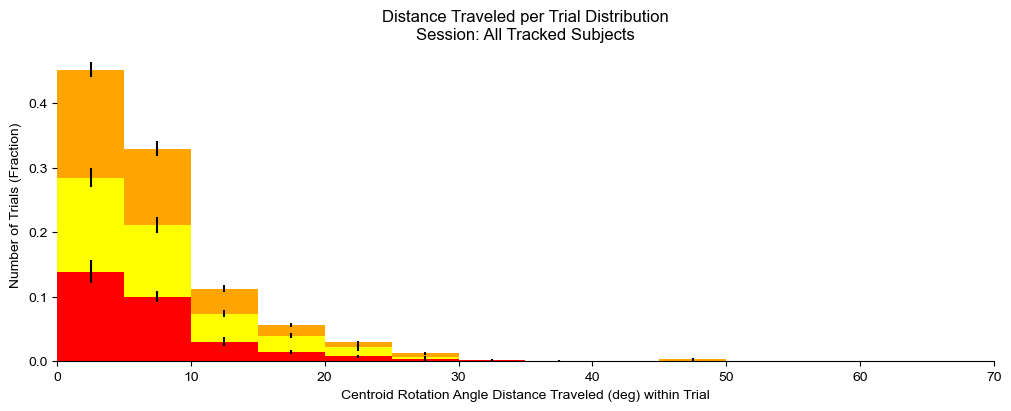

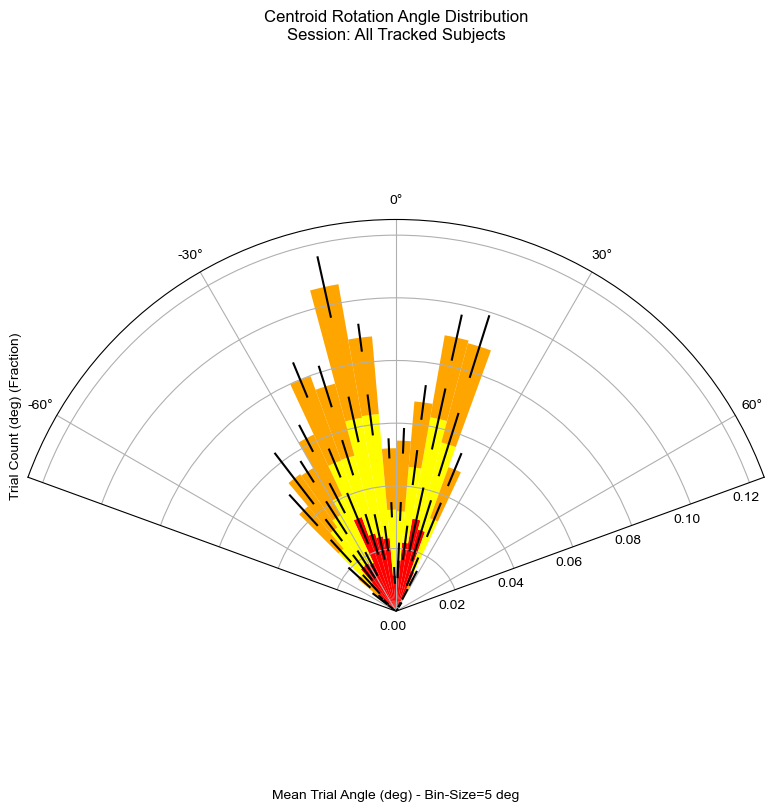

In [21]:
plotCentoids(df_track_centroid, outliers_ratio=0.1,
             choice_normed=False,
             preferred_side_normed=False,
             create_session_plots=False,
             save_fig=global_save_figs)

### All sessions

Plotting centroids for session day1_MLA-73
Saving figure to ..\results\tracking\distance_day1_MLA-73.svg
Saving figure to ..\results\tracking\centroid_rotation_day1_MLA-73.svg


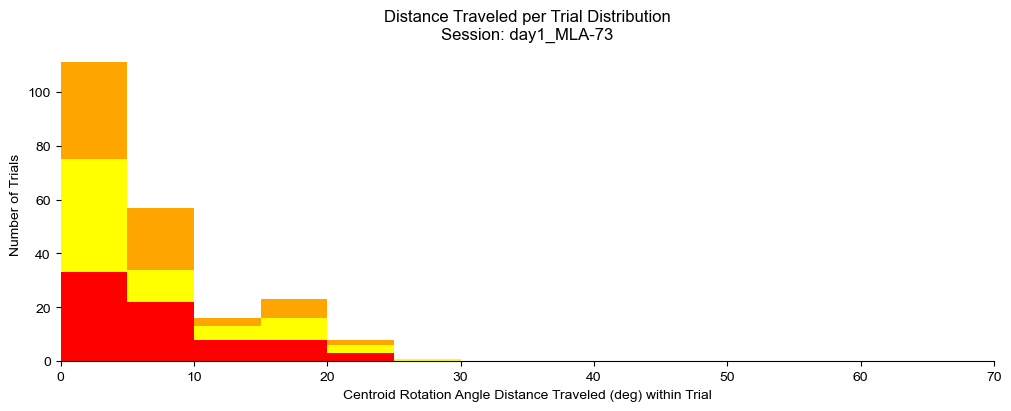

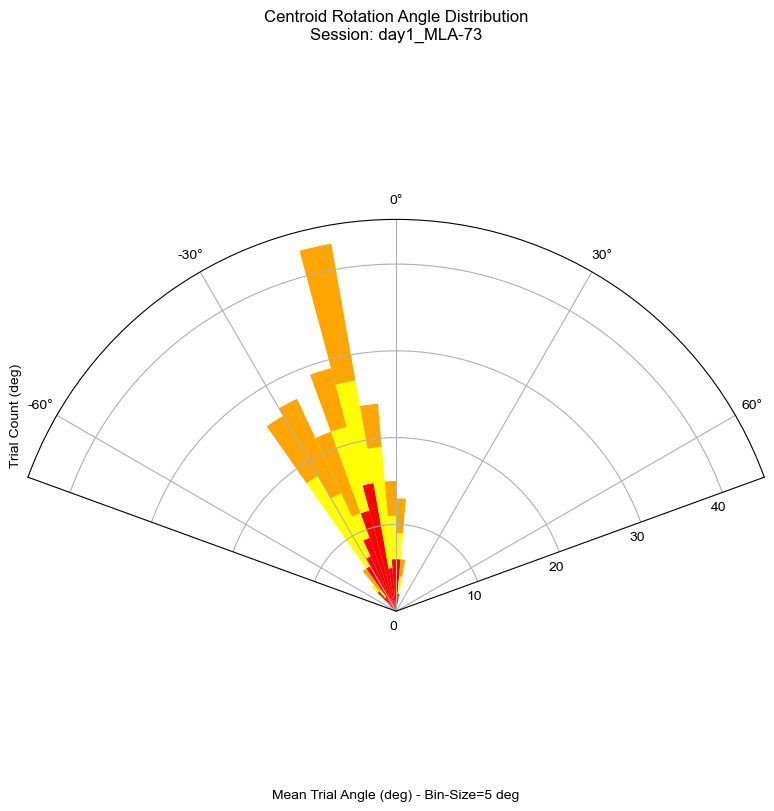

Plotting centroids for session day1_MLA-74
Saving figure to ..\results\tracking\distance_day1_MLA-74.svg
Saving figure to ..\results\tracking\centroid_rotation_day1_MLA-74.svg


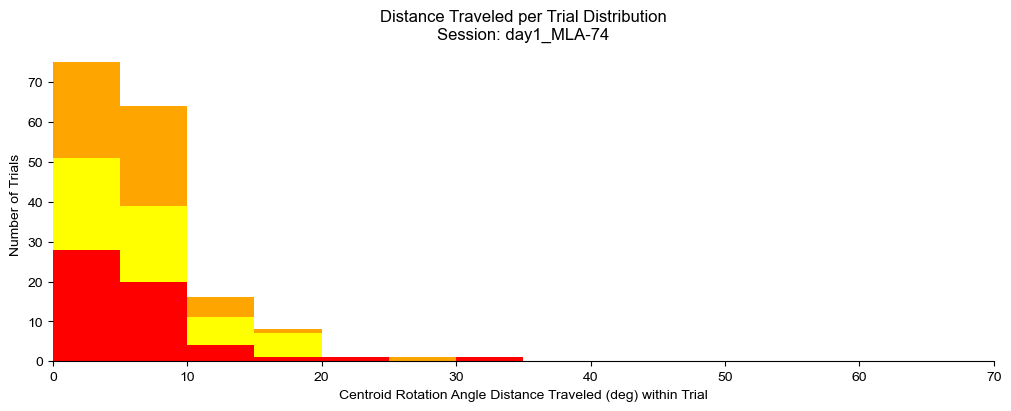

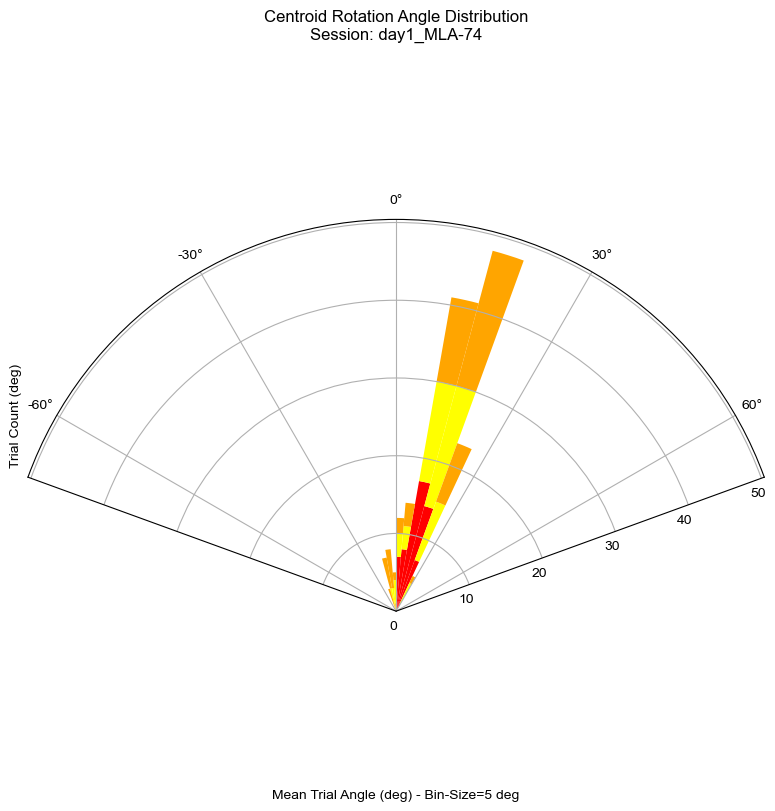

Plotting centroids for session day1_MLA-75
Saving figure to ..\results\tracking\distance_day1_MLA-75.svg
Saving figure to ..\results\tracking\centroid_rotation_day1_MLA-75.svg


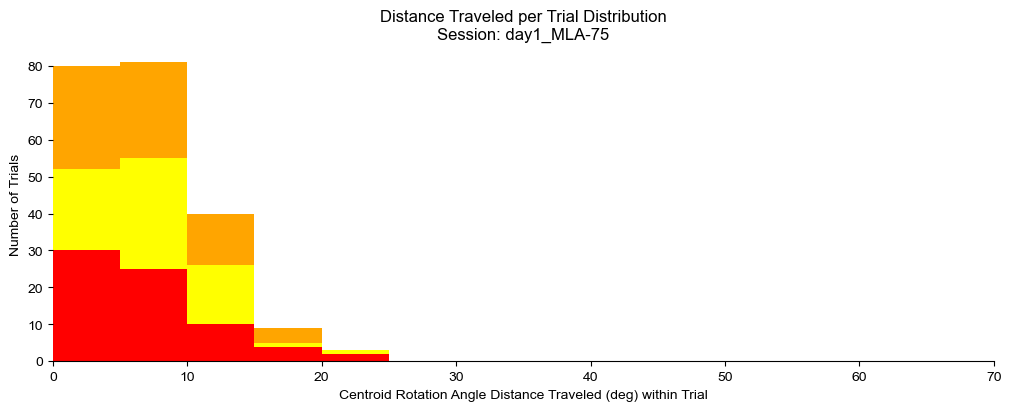

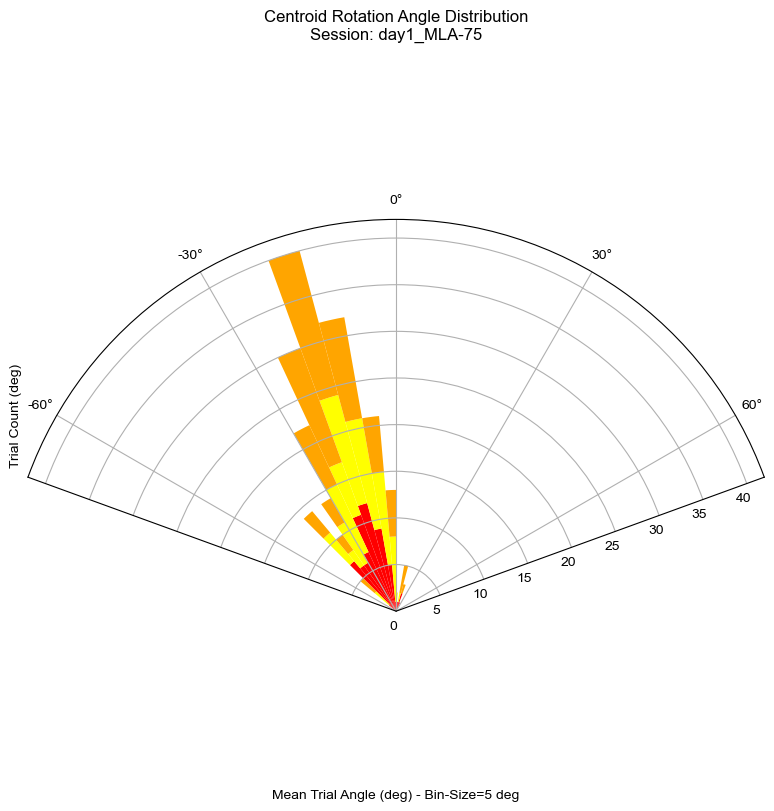

Plotting centroids for session day1_MLA-76
Saving figure to ..\results\tracking\distance_day1_MLA-76.svg
Saving figure to ..\results\tracking\centroid_rotation_day1_MLA-76.svg


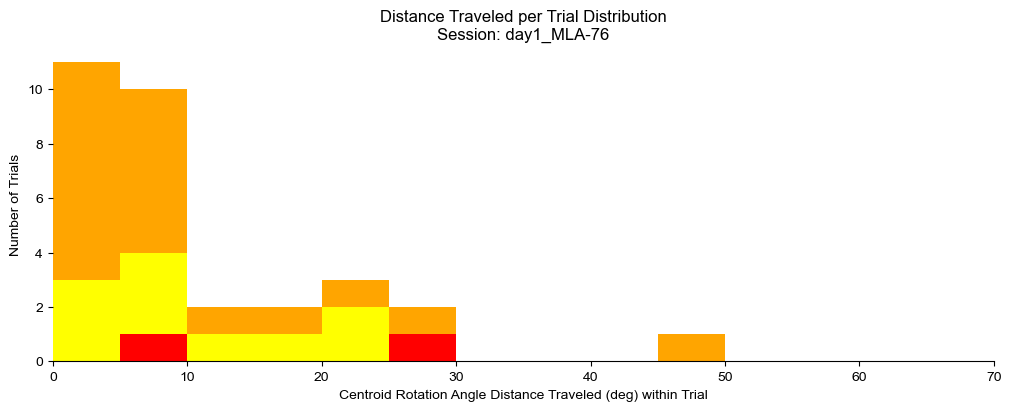

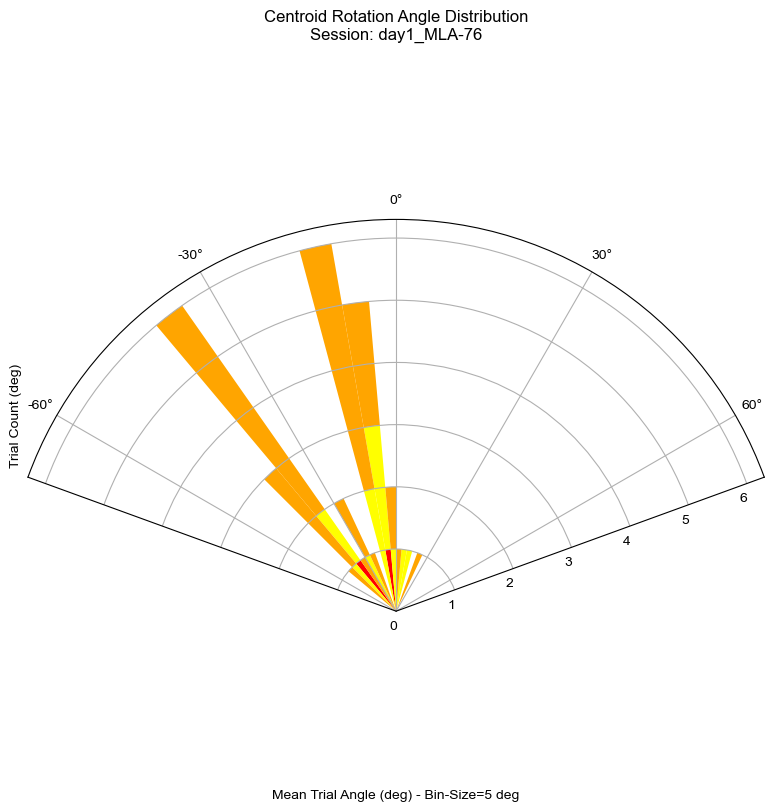

Plotting centroids for session day2_MLA-73
Saving figure to ..\results\tracking\distance_day2_MLA-73.svg
Saving figure to ..\results\tracking\centroid_rotation_day2_MLA-73.svg


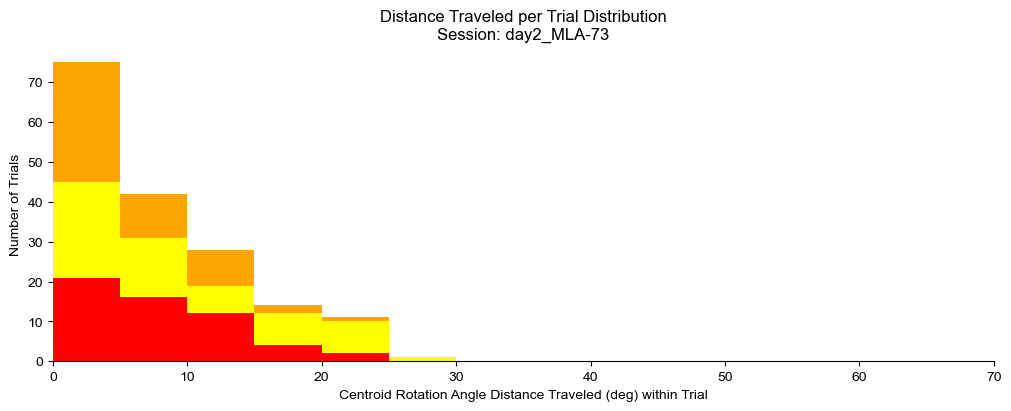

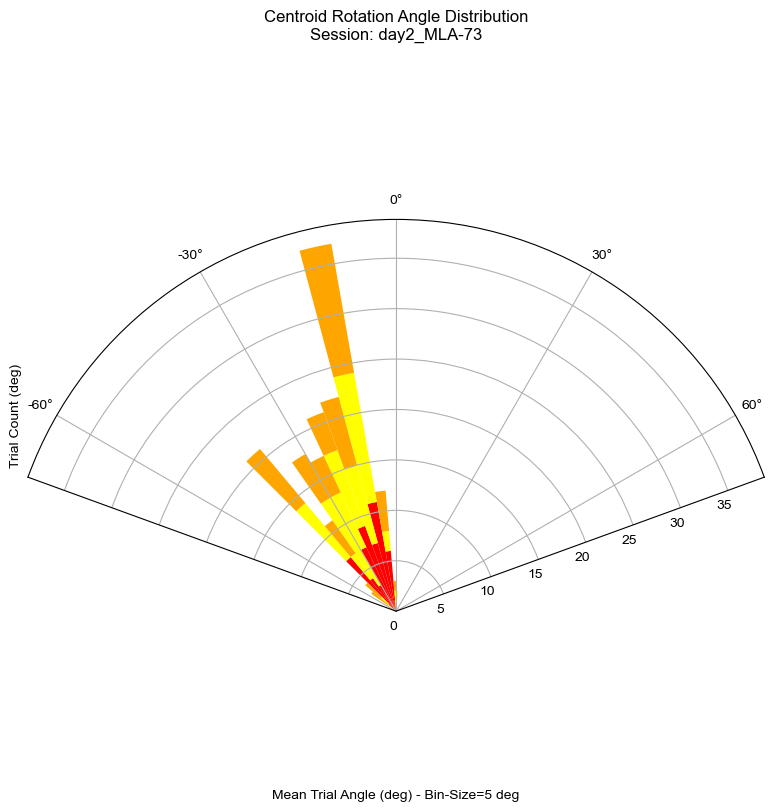

Plotting centroids for session day2_MLA-74
Saving figure to ..\results\tracking\distance_day2_MLA-74.svg
Saving figure to ..\results\tracking\centroid_rotation_day2_MLA-74.svg


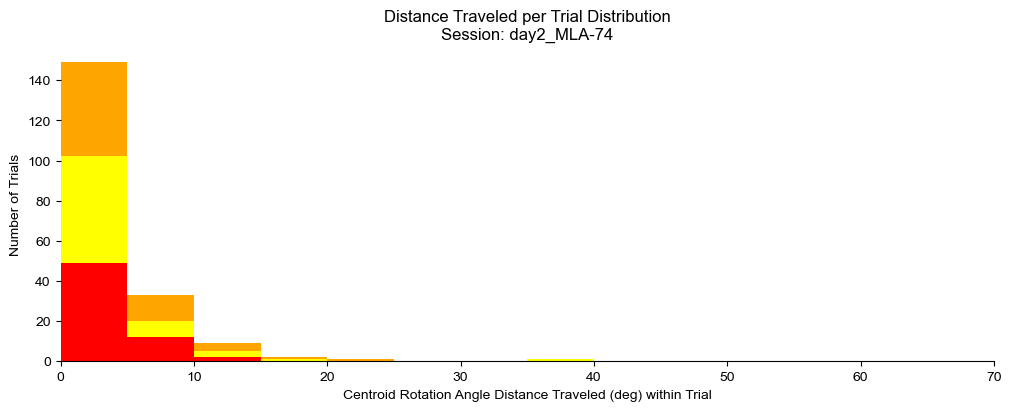

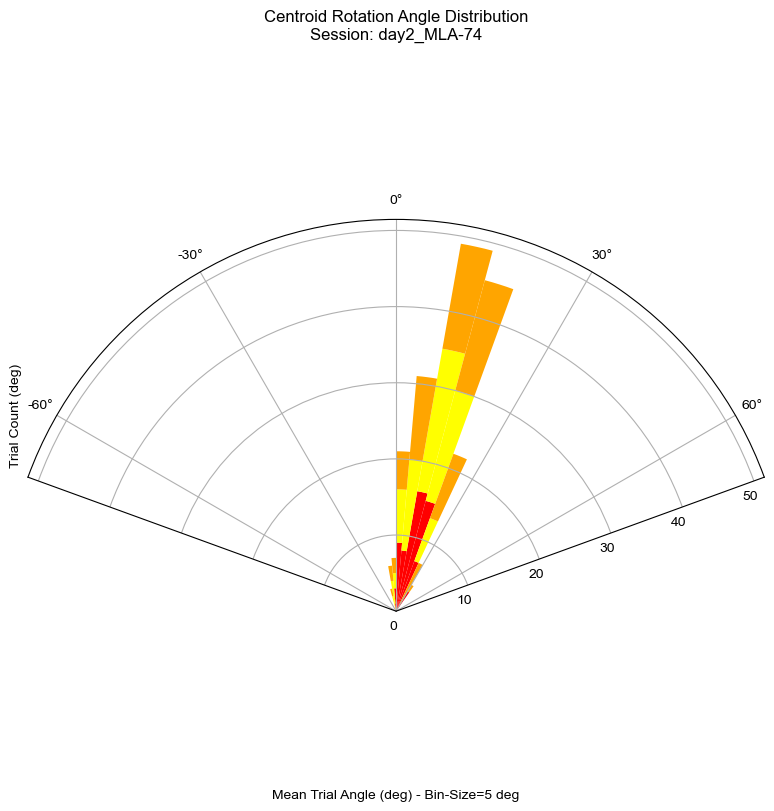

Plotting centroids for session day2_MLA-75
Saving figure to ..\results\tracking\distance_day2_MLA-75.svg
Saving figure to ..\results\tracking\centroid_rotation_day2_MLA-75.svg


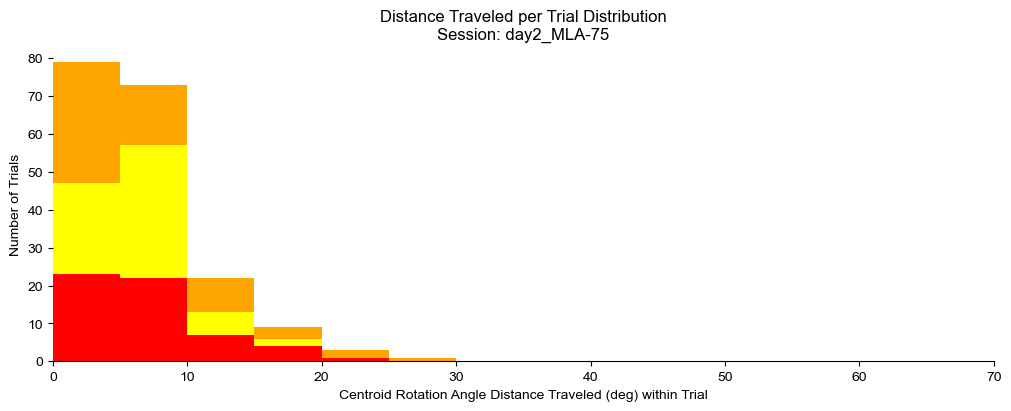

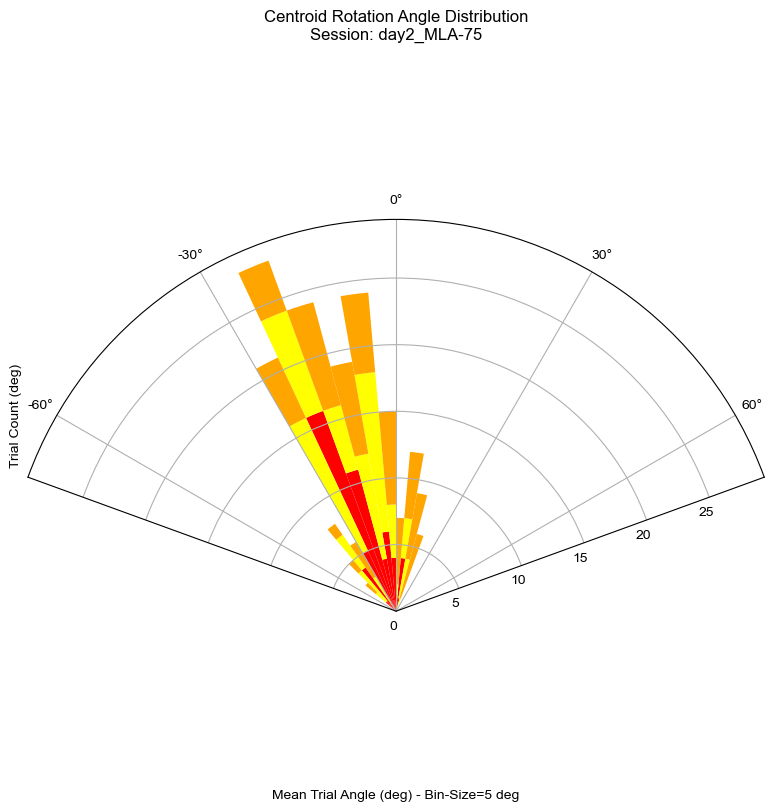

Plotting centroids for session day2_MLA-76
Saving figure to ..\results\tracking\distance_day2_MLA-76.svg
Saving figure to ..\results\tracking\centroid_rotation_day2_MLA-76.svg


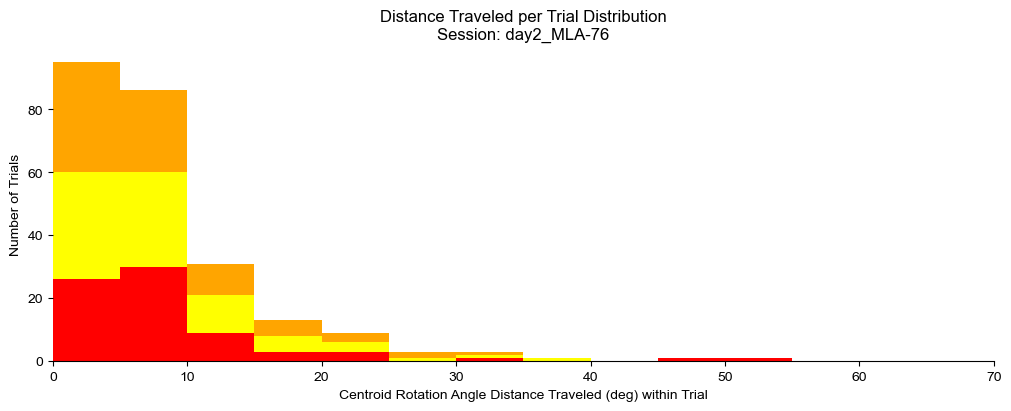

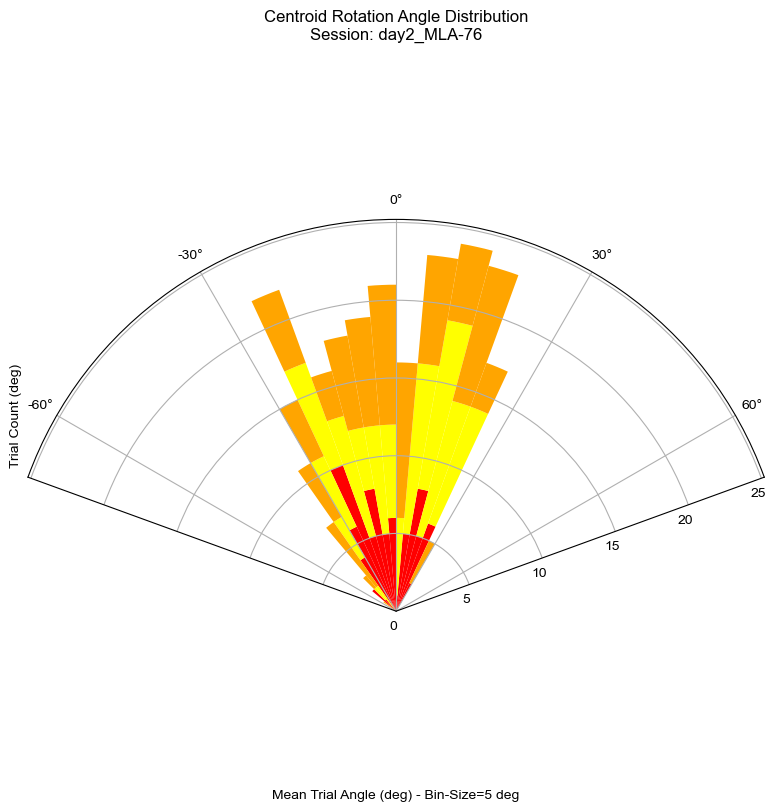

Plotting centroids for session day3_MLA-73
Saving figure to ..\results\tracking\distance_day3_MLA-73.svg
Saving figure to ..\results\tracking\centroid_rotation_day3_MLA-73.svg


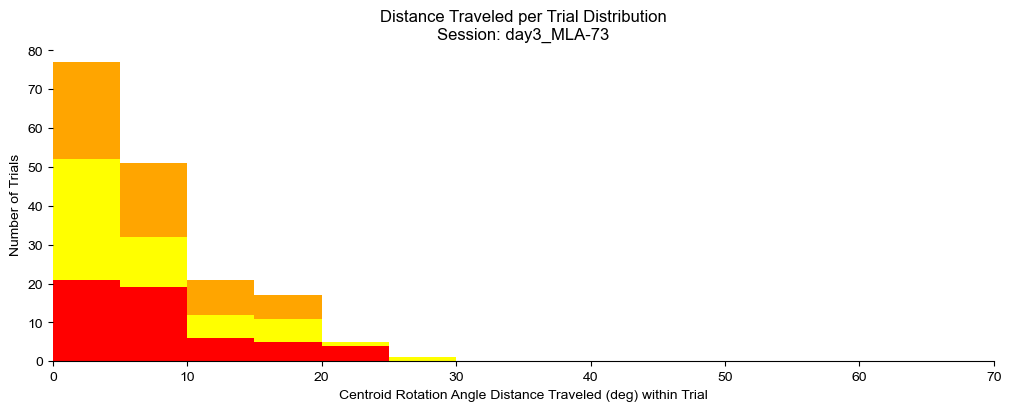

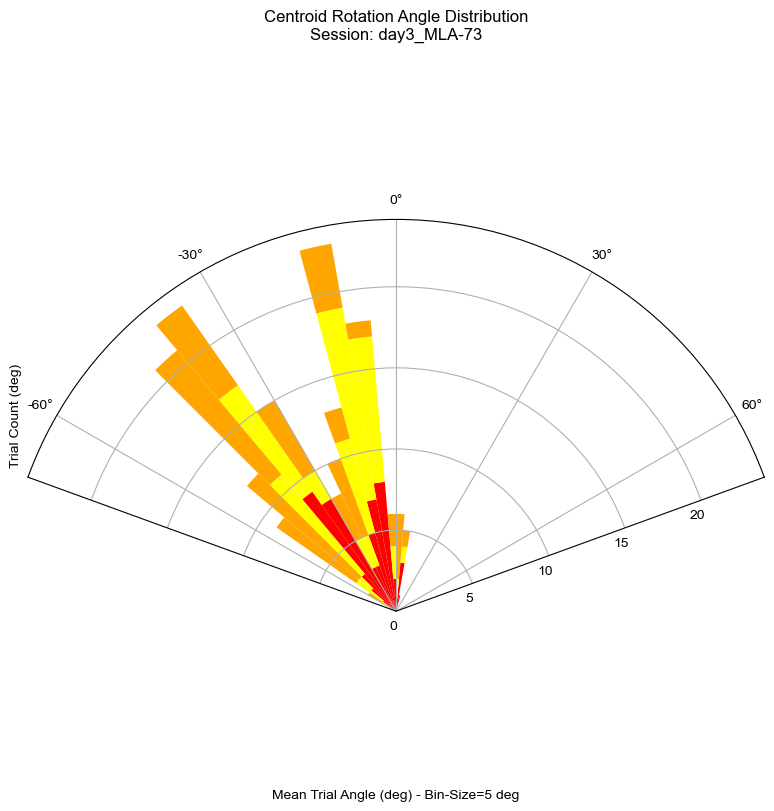

Plotting centroids for session day3_MLA-74
Saving figure to ..\results\tracking\distance_day3_MLA-74.svg
Saving figure to ..\results\tracking\centroid_rotation_day3_MLA-74.svg


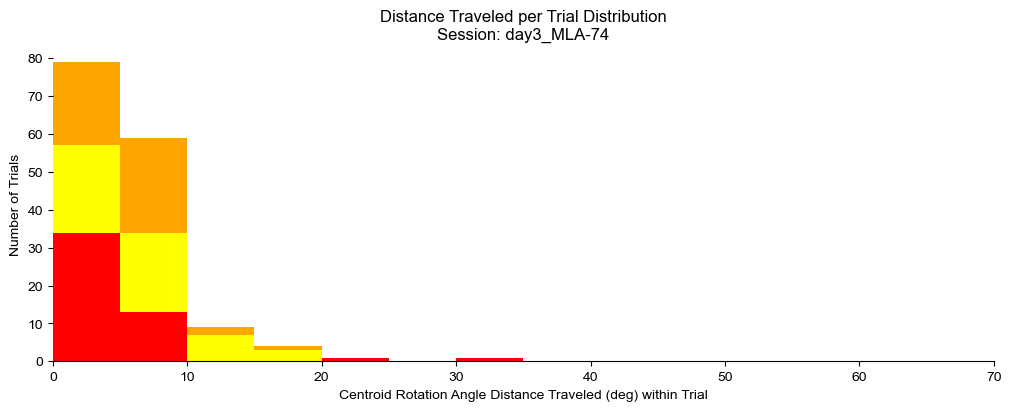

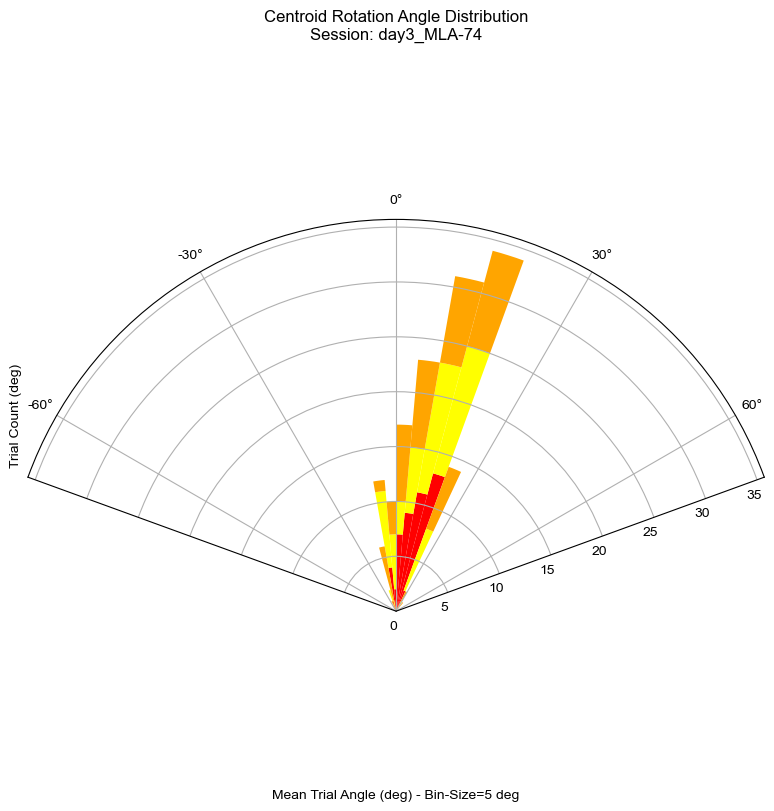

Plotting centroids for session day3_MLA-75
Saving figure to ..\results\tracking\distance_day3_MLA-75.svg
Saving figure to ..\results\tracking\centroid_rotation_day3_MLA-75.svg


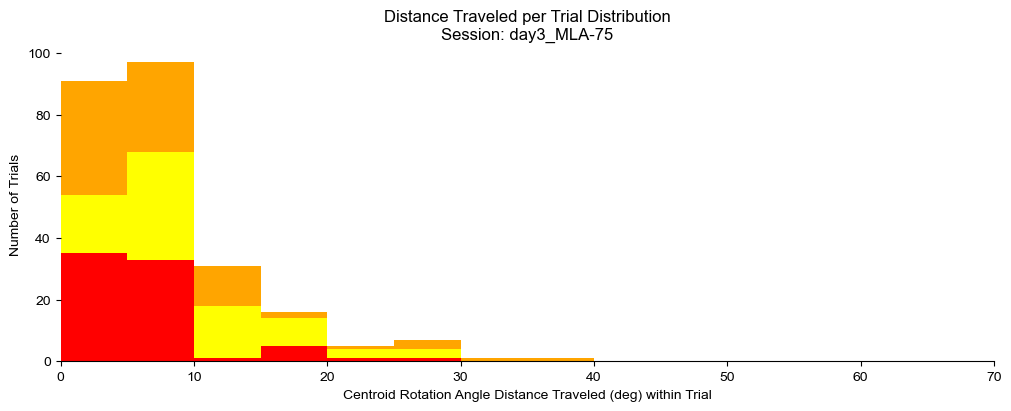

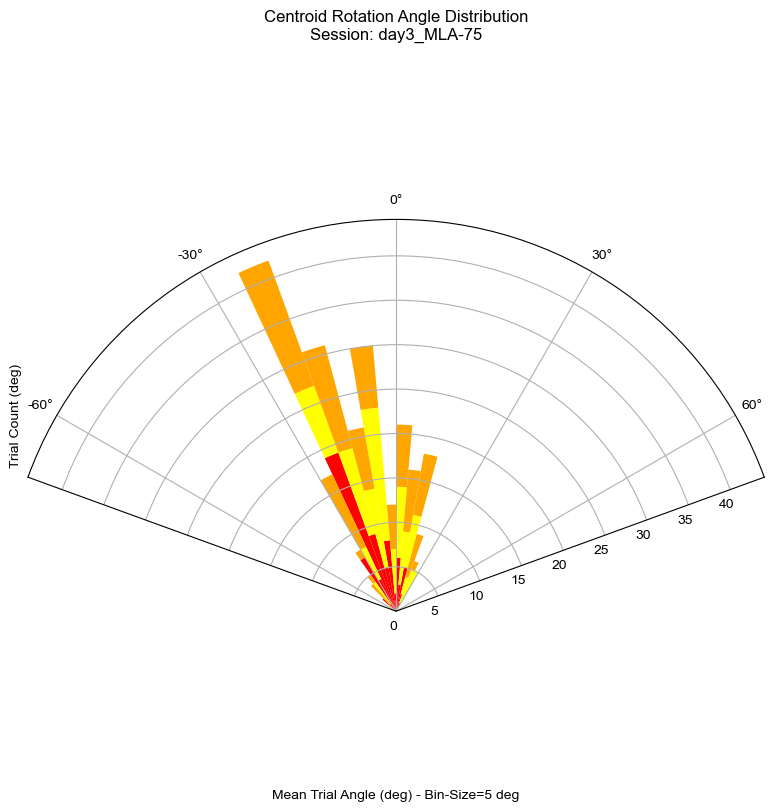

Plotting centroids for session day3_MLA-76
Saving figure to ..\results\tracking\distance_day3_MLA-76.svg
Saving figure to ..\results\tracking\centroid_rotation_day3_MLA-76.svg


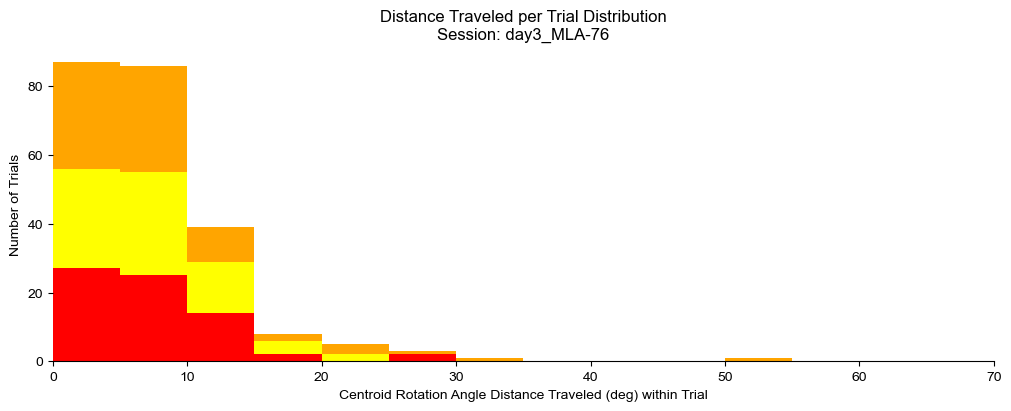

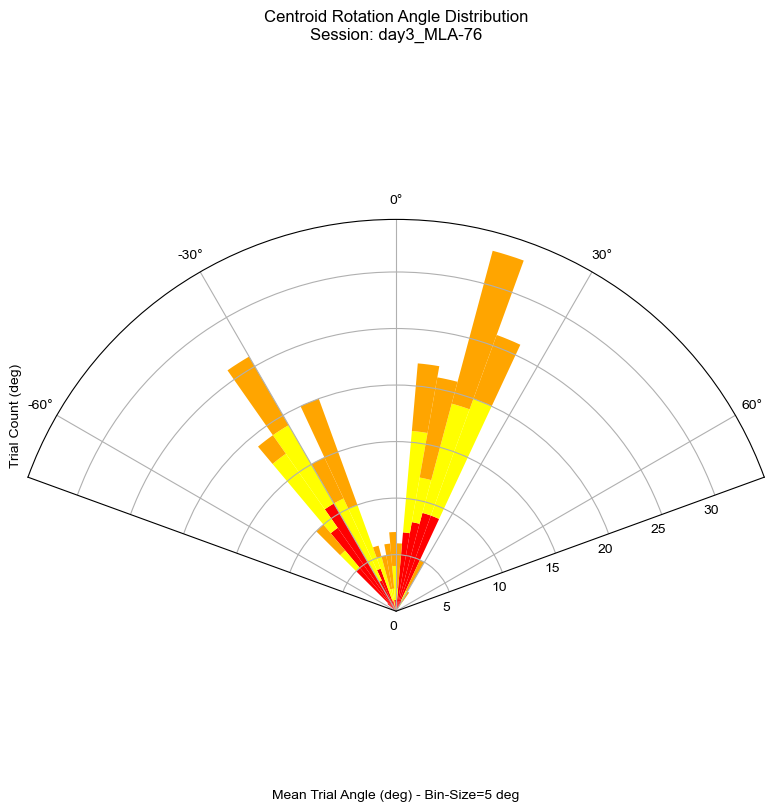

In [22]:
plotCentoids(df_track_centroid, outliers_ratio=0.1,
             choice_normed=False,
             preferred_side_normed=False,
             create_session_plots=True,
             create_all_subjects_plot=False,
             save_fig=global_save_figs)

## Extended Fig. 4d

Plotting centroids for session All Tracked Subjects
Saving figure to ..\results\tracking\centroid_rotation_preferred_All Tracked Subjects.svg


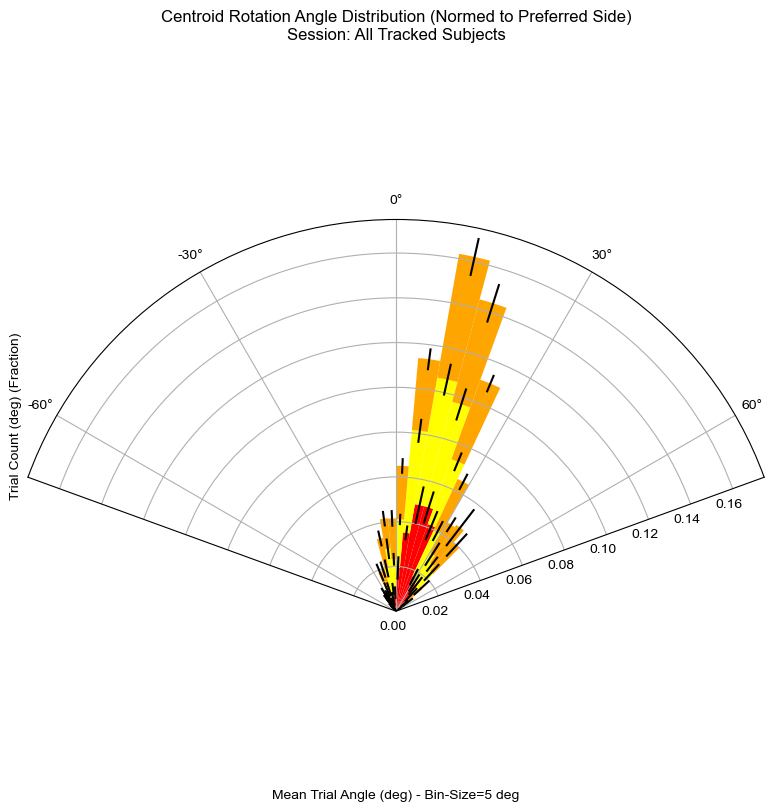

In [23]:
plotCentoids(df_track_centroid, outliers_ratio=0.1,
             choice_normed=False,
             preferred_side_normed=True,
             create_session_plots=False,
             save_fig=global_save_figs)

## Extended Fig. 4e

Filtered sessions without all quantiles: 0 removed, 4 remain.
Session MLA-73 corrected p-value: 0.073, reject null: False
Session MLA-74 corrected p-value: 0.722, reject null: False
Session MLA-75 corrected p-value: 0.105, reject null: False
Session MLA-76 corrected p-value: 0.722, reject null: False
All distributions are not normal: True
Saving figure to ..\results\tracking\strategy_dist_sgf.svg


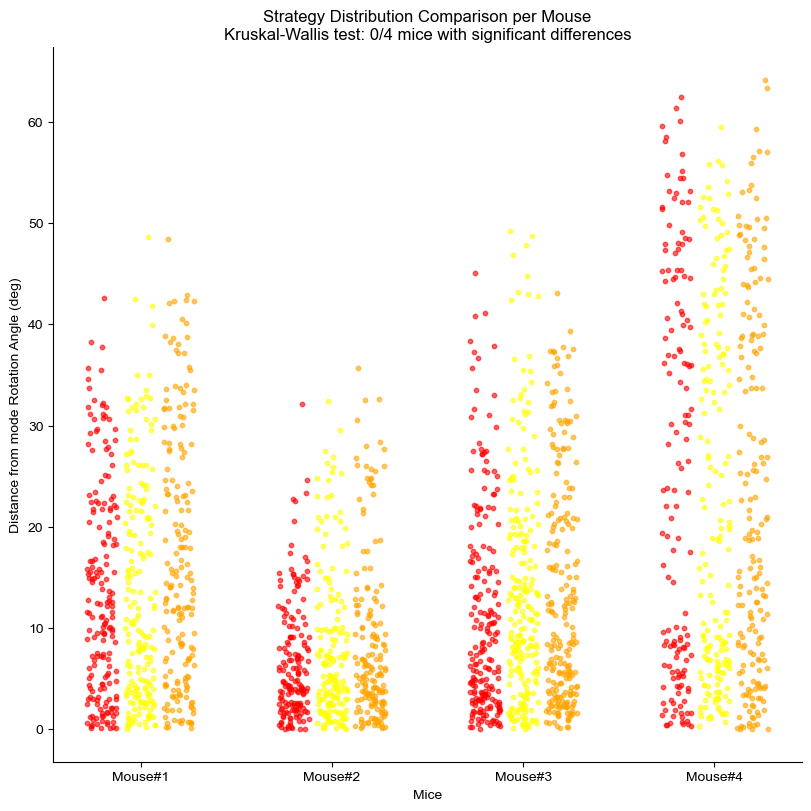

In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

def rotQuantileCorr(df, outliers_ratio : float, save_fig=False):
    quantile_str = {1: "Fast", 2: "Typical", 3: "Slow"}
    quantile_clr = {1: 'red', 2: 'yellow', 3: 'orange'}


    # Remove top and bottom 10% outliers of each trial to avoid detection
    # glitches
    if outliers_ratio > 0:
        df = df.groupby(["Name", "Date", "SessionNum", "TrialNumber"]).apply(
            lambda x: x[
                (x.track_centroid_rotation_angle >= x.track_centroid_rotation_angle.quantile(outliers_ratio)) &
                (x.track_centroid_rotation_angle <= x.track_centroid_rotation_angle.quantile(1 - outliers_ratio))
            ]
        ).reset_index(drop=True)

    # Treat each trial as its mean angle
    df = df.groupby(["Name", "Date", "File", "SessionNum", "quantile_idx", "TrialNumber"]).track_centroid_rotation_angle.mean().reset_index()
    # For each session, find the base angle (most frequent angle) after binning
    # to 5 degree bins
    df['binned_angle'] = (df.track_centroid_rotation_angle / 5).round() * 5
    df_li = []
    for sess, sess_df in df.groupby("Name"):
        base_angle = sess_df['binned_angle'].mode().iloc[0]
        sess_df = sess_df.copy()
        sess_df["base_angle"] = base_angle
        sess_df['abs_angle_from_base'] = sess_df.track_centroid_rotation_angle - base_angle
        sess_df['abs_angle_from_base'] = sess_df['abs_angle_from_base'].abs()
        df_li.append(sess_df)

    df = pd.concat(df_li, ignore_index=True)


    fig, ax = plt.subplots(figsize=(8,8), layout='constrained')

    subj_counts_dict = {}
    # theta = np.radians(degrees_bins[:-1] + BIN_STEP/2)  # Center of each bin
    for quantile_idx, quantile_df in df.groupby("quantile_idx"):
        quantile_color = quantile_clr[quantile_idx]
        for sess, sess_df in quantile_df.groupby("Name"):
            if len(sess_df) < 10:
                continue
            trials_dist_from_base = sess_df['abs_angle_from_base'].values
            if sess not in subj_counts_dict:
                subj_counts_dict[sess] = {}
            subj_counts_dict[sess][quantile_idx] = trials_dist_from_base

    sess_before = len(subj_counts_dict)
    subj_counts_dict = {k:v for k,v in subj_counts_dict.items() if len(v) == 3}
    remove_count = sess_before - len(subj_counts_dict)
    print(f"Filtered sessions without all quantiles: {remove_count} removed, {len(subj_counts_dict)} remain.")

    all_not_normal = True
    sess_pvals = {}
    sess_x = {}
    x_ticks = []
    x_ticklabels = []
    for x, (sess, counts_dict) in enumerate(subj_counts_dict.items()):
        groups_not_normal = True
        for quantile_idx, counts in counts_dict.items():
            quantile_name = quantile_str[quantile_idx]
            quantile_color = quantile_clr[quantile_idx]
            jitter = (np.random.rand(len(counts)) - 0.5) * 0.8
            ax.scatter(jitter + x*5 + quantile_idx - 1, counts,
                       color=quantile_color, s=10,
                       alpha=0.6)
            # Run Shapiro-Wilk test for normality
            shapiro_stat, shapiro_p = stats.shapiro(counts)
            is_normal = shapiro_p > 0.05
            # ax.text(x*5 + quantile_idx - 1, counts.max() + 2,
            #         f"{'N' if is_normal else 'NN'}",
            #         color='r' if is_normal else 'k',
            #         ha='center', va='bottom')
            if is_normal:
                all_not_normal = False
                groups_not_normal = False
        if groups_not_normal:
            # Run Kruskal-Wallis test
            data_groups = [counts_dict[qidx] for qidx in sorted(counts_dict.keys())]
            kw_stat, kw_p = stats.kruskal(*data_groups)
            # print(f"Session {sess} Kruskal-Wallis H-stat={kw_stat:.3f}, p={kw_p:.3f}")
            sess_pvals[sess] = kw_p
        x_center = x*5 + 1
        sess_x[sess] = x_center
        x_ticks.append(x_center)
        x_ticklabels.append(f"Mouse#{x+1}")

    # Multiple comparisons correction
    sess_names = list(sess_pvals.keys())
    p_values = list(sess_pvals.values())
    reject, pvals_corrected, _, _ = multipletests(p_values, method='holm')
    for sess_name, p_corr, rej in zip(sess_names, pvals_corrected, reject):
        print(f"Session {sess_name} corrected p-value: {p_corr:.3f}, reject null: {rej}")
        if rej:
            max_y = max([counts.max() for counts in subj_counts_dict[sess_name].values()])
            max_y += 2
            # Draw bracket
            x = sess_x[sess_name]
            ax.plot([x - 1.5, x - 1.5, x + 1.5, x + 1.5],
                    [max_y, max_y + 0.5, max_y + 0.5, max_y], color='k')
            ax.text(x, max_y + 2,
                    f"*", color='k', ha='center', va='bottom', fontsize=16)

    print(f"All distributions are not normal: {all_not_normal}")
    assert all_not_normal, "Some distributions are normal, check Shapiro-Wilk results above."
    test_str = "Kruskal-Wallis test"
    num_rejected = sum(reject)
    total_sessions = reject.shape[0]
    # Setup axes
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabels)#, rotation=45, ha='right')
    ax.set_title("Strategy Distribution Comparison per Mouse\n"
                 f"{test_str}: {num_rejected}/{total_sessions} mice with significant differences")
    ax.set_xlabel(f"Mice")
    ax.set_ylabel("Distance from mode Rotation Angle (deg)")
    ax.spines[['top', 'right']].set_visible(False)
    if save_fig:
        save_dir = Path(save_prefix)
        fig_path = save_dir / f"strategy_dist_sgf.svg"
        print(f"Saving figure to {fig_path}")
        fig.savefig(fig_path, dpi=300)
    plt.show()


rotQuantileCorr(df_track_centroid, outliers_ratio=0, save_fig=global_save_figs)